## Table of Contents

### Course 1: Supervised Machine Learning — Regression and Classification

**Week 1: Introduction to Machine Learning**
- [Difference between loss function and cost function?](#difference-between-loss-function-and-cost-function)
- [What are other Gradient Descent methods? And when do we use them in ML?](#what-are-other-gradient-descent-methods-and-when-do-we-use-them-in-ml)

**Week 2: Regression with Multiple Input Variables**
- [How do we perform normalisation on data with multiple features? What is standardisation for?](#how-do-we-perform-normalisation-on-data-with-multiple-features-what-is-standardisation-for-and-does-it-do-the-same-thing)
- [When do you perform one-hot encoding? Does it apply only to binary data?](#when-do-you-perform-one-hot-encoding-does-it-apply-only-to-binary-data-or-can-it-be-used-for-continuous-values)
- [When do we use RMSE? Is it the same as MSE?](#when-do-we-use-rmse-is-it-the-same-as-using-mse-how-do-you-interpret-average-error-is-x-units-off)
- [What is r-squared and its relevance to ML?](#what-is-r-squared-and-what-is-its-relevance-to-ml)

**Week 3: Classification**
- [How does regularisation add penalty term to the loss function?](#how-does-regularisation-add-penalty-term-to-the-loss-function)
- [How do we decide between L1 and L2?](#how-do-we-decide-between-l1-and-l2-what-does-it-mean-when-l1-induces-sparsity-while-l2-regularises-weights-since-l2-is-better-than-l1-why-bother-using-l1)
- [Difference between alpha and regularisation?](#difference-between-alpha-and-regularisation)
- [Explain SVM thoroughly](#explain-svm-thoroughly)

---

### Course 2: Advanced Learning Algorithms

**Week 1: Neural Networks**
- *(none of your questions fall in this week)*

**Week 2: Neural Network Training**
- [Where do we use transfer learning? (includes knowledge transfer + coding)](#where-do-we-use-transfer-learning)

**Week 3: Advice for Applying Machine Learning**
- [When and how do we use bias and variance in ML?](#when-and-how-do-we-use-bias-and-variance-in-ml)
- [When do you perform oversampling?](#when-do-you-perform-oversampling-and-how-is-it-for-classification-task-where-there-are-fewer-datapoint-in-a-certain-class-than-others)

**Week 4: Decision Trees**
- *(none of your questions fall here — relevant to your SECOM project's Random Forest/XGBoost work)*

---

### Course 3: Unsupervised Learning, Recommenders, Reinforcement Learning

**Week 1: Unsupervised Learning**
- [How to perform anomaly detection in ML programming?](#how-to-perform-anomaly-detection-in-ml-programming)

**Week 2: Recommender Systems** *(PCA taught as part of this week)*
- [How does PCA transformation help in ML?](#how-does-the-transformation-of-data-for-pca-help-in-ml-which-step-does-pca-come-in-when-performing-ml)
- [What type of machine learning is Recommendation?](#what-type-of-machine-learning-is-recommendation)

**Week 3: Reinforcement Learning**
- [What is Markov Chains and why do we need them in ML?](#what-is-markov-chains-and-why-do-we-need-them-in-ml)

---

### Statistics / Math for ML

**Testing for normality:**
- [Why do we need to know if a dataset is normally distributed? What kind of ML uses it?](#why-do-we-need-to-know-if-a-dataset-is-normally-distributed-what-kind-of-ml-uses-it)
- [D'Agostino's K² test](#dagostinos-k-test)

**Hypothesis testing framework:**
- [What is and why do we need hypothesis testing in ML?](#what-is-and-why-do-we-need-hypothesis-testing-in-ml)

**Comparing means between groups — core:**
- [What is and why do we need t-test in ML?](#what-is-and-why-do-we-need-t-test-in-ml)
- [ANOVA — compares means across three or more groups](#anova-analysis-of-variance)

**Measuring relationships between variables — core:**
- [Pearson correlation — linear relationship between two continuous variables](#pearson-correlation)
- [Chi-square test — association between two categorical variables](#chi-square-test)

**Comparing distributions — core:**
- [Kolmogorov-Smirnov (KS) test — whether two samples come from the same distribution; used for detecting data drift in production](#kolmogorov-smirnov-ks-test)

**Probability foundations:**
- [Explain shortly what Bayes Theorem is. Then explain how it is applicable in ML.](#explain-shortly-what-bayes-theorem-is-then-explain-how-it-is-applicable-in-ml)

**Lower priority (know they exist, reference when needed):**
- Spearman correlation — non-linear/ranked version of Pearson
- Mann-Whitney U test — non-parametric alternative to t-test

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# make_classification generates a synthetic dataset for classification tasks —
# useful here because it's fast, clean, and lets us control exactly how "learnable" it is
X, y = make_classification(
    n_samples=500,        # total number of rows (data points) to generate
    n_features=10,        # total number of columns (features) per row
    n_informative=6,      # how many of those features actually carry signal (predictive of y)
    n_redundant=2,        # how many features are linear combinations of the informative ones (fake signal, tests regularization)
    n_classes=2,          # binary classification (0 or 1)
    weights=[0.7, 0.3],   # class balance — 70% class 0, 30% class 1 (mimics imbalance like SECOM pass/fail)
    random_state=42       # seed for reproducibility — same seed = same "random" data every run
)

# train_test_split separates data into a training set (to fit the model)
# and a test set (to evaluate it on unseen data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% of data held out for testing, 80% for training
    random_state=42    # same seed ensures the same split every time you rerun
)

print(X_train.shape, X_test.shape)

(400, 10) (100, 10)


# 1. Supervised Learning (Course 1)

### How does regularisation add penalty term to the loss function?

Regularization is added to the **cost function** (not the per-example loss), as an extra penalty term based on the model's weights:

- **L2 (Ridge):** $J(w,b) = \frac{1}{m}\sum L(\hat{y}^{(i)}, y^{(i)}) + \frac{\lambda}{2m}\sum_{j} w_j^2$
- **L1 (Lasso):** $J(w,b) = \frac{1}{m}\sum L(\hat{y}^{(i)}, y^{(i)}) + \frac{\lambda}{m}\sum_{j} |w_j|$

`alpha` (or `λ`/lambda in Ng's notation) is the **regularization strength**. Higher alpha = simpler model (more bias, less variance). Alpha = 0 means no regularization.

**Careful:** in `LogisticRegression`, sklearn uses `C` instead of `alpha`, and `C` is the **inverse** of regularization strength (`C = 1/λ`). Smaller `C` = stronger regularization.

**Key parameters:**
- `alpha` (Ridge/Lasso/ElasticNet) — regularization strength, tune via `RidgeCV`/`GridSearchCV`
- `C` (LogisticRegression, SVC) — inverse regularization strength
- `penalty` — `'l1'`, `'l2'`, `'elasticnet'`, or `None`
- `solver` — `'liblinear'` supports L1, `'lbfgs'` (default) only supports L2

[⬆ Back to top](#table-of-contents)

**Code:** Fitting Ridge (L2) and Lasso (L1) regression models and comparing their learned coefficients.

In [2]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Note: Ridge/Lasso are regression models. Our y_train is binary (0/1) from
# make_classification, so this is just to illustrate how alpha affects the
# coefficients numerically — not a meaningful classification model.

# Ridge = L2 regularization
ridge = Ridge(
    alpha=1.0   # regularization strength (this is lambda). Higher = more shrinkage, simpler model
)
ridge.fit(X_train, y_train)

# Lasso = L1 regularization
lasso = Lasso(
    alpha=1.0,      # same role as Ridge's alpha, but L1 penalty can push coefficients to exactly 0
    max_iter=10000  # Lasso uses an iterative solver (coordinate descent) — raised so it converges
)
lasso.fit(X_train, y_train)

print("Ridge coefficients:", ridge.coef_)  # coef_ = the learned weight for each feature
print("Lasso coefficients:", lasso.coef_)  # compare: some Lasso coefficients may be exactly 0.0

Ridge coefficients: [ 0.16450909  0.04714524  0.00922872 -0.0313814   0.0769415   0.00787293
 -0.00152559 -0.0020064  -0.01357682  0.09764872]
Lasso coefficients: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


**Code:** Fitting a regularized logistic regression classifier and inspecting its learned weights.

In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='l2',     # type of regularization: 'l1', 'l2', 'elasticnet', or None
    C=1.0,             # inverse regularization strength (C = 1/alpha) — smaller C = stronger regularization
    solver='lbfgs',    # optimization algorithm used to fit the model; 'lbfgs' only supports l2/None
    max_iter=1000      # max number of iterations for the solver to converge
)
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)  # one weight per feature
print("Intercept:", model.intercept_)  # the bias term

Coefficients: [[ 1.28779711  0.37744297  0.09475127 -0.17936272  0.53528576  0.04227776
   0.01194893  0.05729861 -0.13128468  0.82775249]]
Intercept: [0.05700934]


/opt/anaconda3/envs/dsprint/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


**Code:** Visualizing how increasing alpha shrinks coefficients differently for Ridge (L2) vs Lasso (L1) — this is where you can *see* Lasso's sparsity property (coefficients hitting exactly 0) vs Ridge's smooth shrinkage.

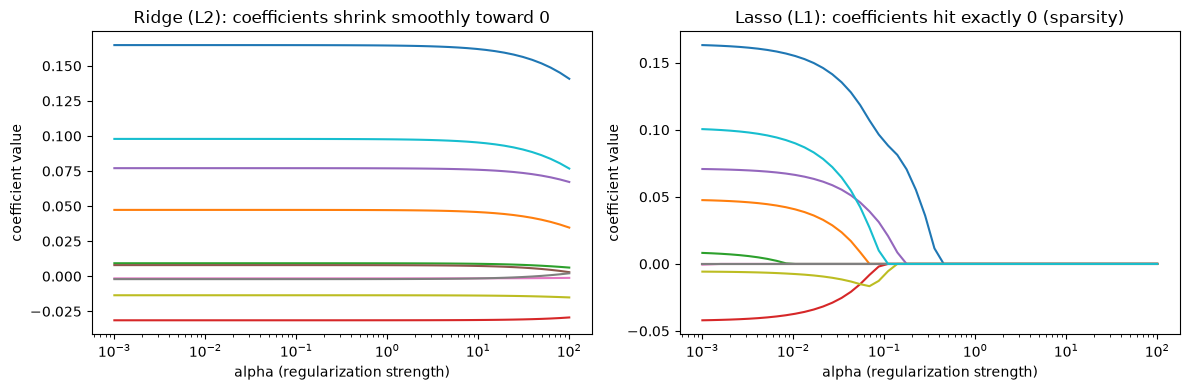

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

# Test a range of alpha values, log-spaced since regularization effects are non-linear
alphas = np.logspace(-3, 2, 50)  # 50 values from 0.001 to 100

ridge_coefs = []  # will hold the weight vector at each alpha, for Ridge
lasso_coefs = []  # same, for Lasso

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)  # shape: (n_alphas, n_features)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 side-by-side plots

axes[0].plot(alphas, ridge_coefs)
axes[0].set_xscale('log')  # log scale x-axis since alpha spans orders of magnitude
axes[0].set_xlabel('alpha (regularization strength)')
axes[0].set_ylabel('coefficient value')
axes[0].set_title('Ridge (L2): coefficients shrink smoothly toward 0')

axes[1].plot(alphas, lasso_coefs)
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha (regularization strength)')
axes[1].set_ylabel('coefficient value')
axes[1].set_title('Lasso (L1): coefficients hit exactly 0 (sparsity)')

plt.tight_layout()
plt.show()

### How do we perform normalisation on data with multiple features? What is standardisation for, and does it do the same thing?

**Normalisation** rescales feature values onto a common range (commonly [0,1]), so that no single feature dominates a model just because of its raw magnitude (e.g. "salary in dollars" vs. "age in years").

**Standardisation** rescales each feature to have **mean = 0** and **standard deviation = 1** (z-score scaling): z = (x - mean) / std.

**Functionally different, not the same:**

| | Normalisation (MinMaxScaler) | Standardisation (StandardScaler) |
|---|---|---|
| Output range | Fixed, e.g. [0,1] | Unbounded — centered at 0 |
| Sensitive to outliers | Yes — a single extreme value compresses everything else | Less sensitive, but still affected |
| Assumes normal distribution | No | Works best when data is roughly Gaussian, not strictly required |
| Best for | Algorithms needing bounded input (e.g. neural net inputs) | Algorithms assuming centered data (PCA, linear/logistic regression, SVM, distance/gradient-based methods) |

**Rule of thumb:** standardisation is the more common default in classical ML — especially before PCA, since PCA looks for directions of maximum variance, and unscaled features with larger raw ranges would dominate the variance calculation artificially.

**With multiple features:** each feature is scaled **independently**, using only that feature's own min/max (or mean/std) — not across features. A dataset with 10 features gets 10 separate column-wise transformations.

**When to use either:** gradient descent-based models (linear/logistic regression, neural nets), distance-based models (KNN, K-means, SVM), and PCA. Tree-based models (Random Forest, XGBoost) generally don't need scaling, since splits are based on order, not magnitude.

**Pipeline stage:** both are **preprocessing / feature engineering** steps, done **after train/test split, before model fitting**:

`Raw data → Train/test split → Fit scaler on train only → Transform train & test → Fit model on scaled train data → Evaluate on scaled test data`

Fitting a scaler on the full dataset (before splitting) causes **data leakage** — the scaler would "see" test data statistics during training, giving an overly optimistic evaluation later.

**Practical note for SECOM:** with 591 features on different sensor scales, scaling isn't optional — it's a required step before PCA or any distance/gradient-based model.

**Code:** Applying MinMaxScaler to scale multiple features into the [0,1] range, and comparing feature ranges before vs. after.

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# MinMaxScaler rescales each feature independently to a target range (default 0 to 1)
# formula per feature: (x - min) / (max - min)
scaler = MinMaxScaler(
    feature_range=(0, 1)  # target range after scaling — (0,1) is standard, but can be changed e.g. (-1,1)
)

# IMPORTANT: fit the scaler ONLY on training data (learns min/max from X_train),
# then use the SAME fitted scaler to transform test data — this avoids data leakage
X_train_minmax = scaler.fit_transform(X_train)   # learns min/max AND transforms in one step
X_test_minmax = scaler.transform(X_test)         # only transforms, using min/max learned from X_train

print("Before scaling — min/max per feature (train):")
print(np.round(X_train.min(axis=0), 2))
print(np.round(X_train.max(axis=0), 2))

print("\nAfter scaling — min/max per feature (train):")
print(np.round(X_train_minmax.min(axis=0), 2))  # should all be ~0.0
print(np.round(X_train_minmax.max(axis=0), 2))  # should all be ~1.0

Before scaling — min/max per feature (train):
[-5.   -4.33 -2.63 -4.66 -5.44 -6.47 -2.93 -6.8  -4.59 -4.93]
[4.94 6.01 2.87 5.07 3.62 8.35 3.24 5.28 6.56 3.1 ]

After scaling — min/max per feature (train):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Code:** Visualizing feature scales before vs. after normalisation.

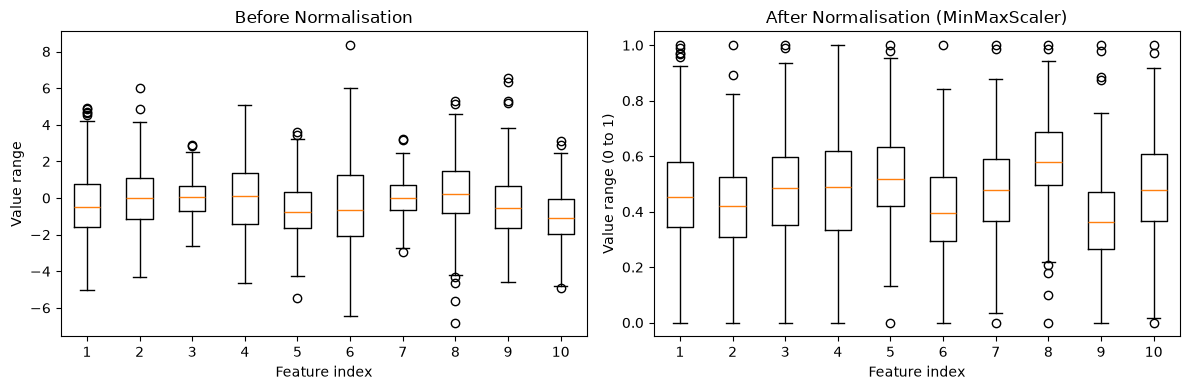

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot before scaling — features on very different scales are hard to compare
axes[0].boxplot(X_train)
axes[0].set_title('Before Normalisation')
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Value range')

# Boxplot after scaling — all features now sit within [0, 1]
axes[1].boxplot(X_train_minmax)
axes[1].set_title('After Normalisation (MinMaxScaler)')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('Value range (0 to 1)')

plt.tight_layout()
plt.show()

**Code:** Applying StandardScaler instead, and comparing its output distribution to MinMaxScaler's — this shows the key difference: StandardScaler centers at 0 with no fixed upper/lower bound, while MinMaxScaler is bounded to [0,1].

StandardScaler — mean per feature (train, should be ~0):
[-0. -0.  0.  0. -0.  0. -0.  0.  0. -0.]
StandardScaler — std per feature (train, should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


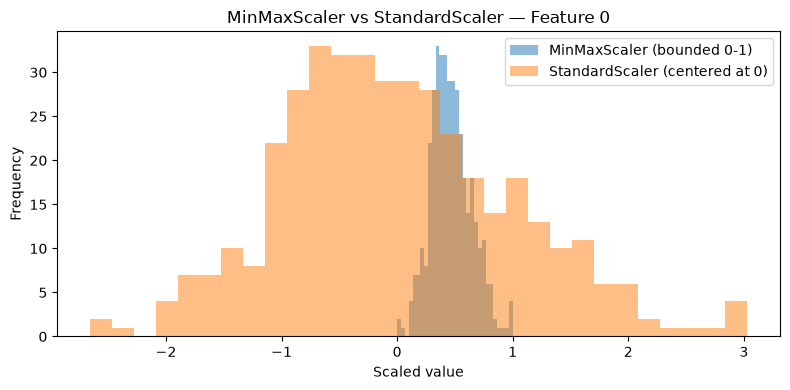

In [7]:
from sklearn.preprocessing import StandardScaler

# StandardScaler transforms each feature to mean=0, std=1
# formula per feature: (x - mean) / std
std_scaler = StandardScaler()

X_train_std = std_scaler.fit_transform(X_train)  # fit on train only, then transform
X_test_std = std_scaler.transform(X_test)        # transform test using train's mean/std

print("StandardScaler — mean per feature (train, should be ~0):")
print(np.round(X_train_std.mean(axis=0), 2))
print("StandardScaler — std per feature (train, should be ~1):")
print(np.round(X_train_std.std(axis=0), 2))

# Side-by-side comparison of the two scaling methods on the same feature
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train_minmax[:, 0], bins=30, alpha=0.5, label='MinMaxScaler (bounded 0-1)')
ax.hist(X_train_std[:, 0], bins=30, alpha=0.5, label='StandardScaler (centered at 0)')
ax.set_xlabel('Scaled value')
ax.set_ylabel('Frequency')
ax.set_title('MinMaxScaler vs StandardScaler — Feature 0')
ax.legend()
plt.tight_layout()
plt.show()

### When do you perform one-hot encoding? Does it apply only to binary data, or can it be used for continuous values?

**One-hot encoding** converts a **categorical** feature (a column with discrete, non-numeric or non-ordinal categories) into multiple binary (0/1) columns — one column per category. E.g. a `color` column with values `red`, `blue`, `green` becomes 3 columns: `color_red`, `color_blue`, `color_green`, each 0 or 1.

**When to use it:** only on **categorical** (nominal) features — i.e. features where the categories have **no inherent order** (color, country, machine ID, defect type). It's not limited to binary categories — it works for any number of categories (2, 3, 50, etc.), though with very high cardinality (hundreds of categories) it creates a lot of sparse columns, which can hurt some models.

**Does NOT apply to continuous values.** Continuous numeric features (age, temperature, sensor reading) should be scaled (normalisation/standardisation), not one-hot encoded — one-hot encoding treats each unique value as a separate category, which is meaningless (and computationally disastrous) for continuous data.

**Important distinction — nominal vs. ordinal categories:**
- **Nominal** (no order, e.g. `red/blue/green`) → one-hot encoding
- **Ordinal** (has order, e.g. `low/medium/high`) → often better as **ordinal/label encoding** (0, 1, 2), preserving the rank, since one-hot encoding would throw away that ordering information

**Pipeline stage:** preprocessing / feature engineering — same stage as scaling, done **after train/test split** (fit the encoder on train categories only, to avoid leaking unseen category info from test into train).

**Code:** One-hot encoding a categorical feature, and comparing it to ordinal (label) encoding for an ordinal feature — showing why the choice depends on whether the categories have order.

In [8]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Small example DataFrame — separate from X_train/X_test since this needs
# categorical columns, which our synthetic numeric dataset doesn't have
df = pd.DataFrame({
    'machine_id': ['M1', 'M2', 'M3', 'M1', 'M2'],       # nominal — no order → one-hot encode
    'defect_severity': ['low', 'high', 'medium', 'low', 'high']  # ordinal — has order → ordinal encode
})

# --- One-hot encoding (for nominal category: machine_id) ---
ohe = OneHotEncoder(
    sparse_output=False,   # return a regular dense array instead of a sparse matrix (easier to read here)
    handle_unknown='ignore'  # if test data has a category not seen in train, encode it as all-zeros instead of erroring
)
machine_encoded = ohe.fit_transform(df[['machine_id']])  # fit_transform expects a 2D input, hence [[...]]
machine_encoded_df = pd.DataFrame(
    machine_encoded,
    columns=ohe.get_feature_names_out(['machine_id'])  # generates column names like machine_id_M1, machine_id_M2...
)
print("One-hot encoded (machine_id):")
print(machine_encoded_df)

# --- Ordinal encoding (for ordinal category: defect_severity) ---
ordinal = OrdinalEncoder(
    categories=[['low', 'medium', 'high']]  # explicitly define the order — otherwise sklearn picks alphabetical, which may be wrong
)
severity_encoded = ordinal.fit_transform(df[['defect_severity']])
print("\nOrdinal encoded (defect_severity), low=0, medium=1, high=2:")
print(severity_encoded.flatten())

One-hot encoded (machine_id):
   machine_id_M1  machine_id_M2  machine_id_M3
0            1.0            0.0            0.0
1            0.0            1.0            0.0
2            0.0            0.0            1.0
3            1.0            0.0            0.0
4            0.0            1.0            0.0

Ordinal encoded (defect_severity), low=0, medium=1, high=2:
[0. 2. 1. 0. 2.]


**Code:** Using pandas' get_dummies as a quicker alternative to sklearn's OneHotEncoder for simple one-off encoding.

In [9]:
# pd.get_dummies is a simpler pandas shortcut for one-hot encoding —
# convenient for quick EDA, but sklearn's OneHotEncoder is preferred inside
# a proper ML pipeline (it can fit on train and transform test consistently)
dummies = pd.get_dummies(
    df['machine_id'],
    prefix='machine_id'  # prefix added to each new column name
)
print(dummies)

   machine_id_M1  machine_id_M2  machine_id_M3
0           True          False          False
1          False           True          False
2          False          False           True
3           True          False          False
4          False           True          False


### When do you perform oversampling, and is it for classification tasks with fewer datapoints in a certain class?

**Oversampling** is a technique to address **class imbalance** in classification tasks — where one class has significantly fewer examples than another (e.g. SECOM: far more "pass" than "fail" samples). It works by **increasing the number of minority-class samples** (either duplicating them or generating synthetic ones) so the model doesn't just learn to always predict the majority class.

**When to use it:** whenever your classification target is imbalanced enough that a naive model could get high accuracy just by ignoring the minority class entirely.

**What is a "naive model" here?** A naive model is one that predicts the **majority class every single time**, with no actual learning involved — e.g. always predicting "pass." If 95% of SECOM samples are "pass," this naive strategy gets 95% accuracy while being completely useless (it never catches a single defect). This is why accuracy alone is a misleading metric on imbalanced data, and why oversampling (plus metrics like precision/recall/F1) matters — you want the model to actually learn to distinguish classes, not just exploit the imbalance.

This is extremely common in fault/defect detection (like SECOM), fraud detection, and rare disease diagnosis — the class you actually care about (the "fail"/"fraud"/"disease" case) is usually the rare one.

**Yes** — it's specifically a classification concept, applied when there are fewer datapoints in one class relative to others.

**Main oversampling methods:**
- **Random oversampling** — duplicates existing minority-class rows at random (simple, but risks overfitting since it doesn't add new information, just repeats it)
- **SMOTE** (Synthetic Minority Oversampling Technique) — generates *new*, synthetic minority-class samples by interpolating between existing minority samples and their nearest neighbours, rather than just copying

**Alternative approach — undersampling:** instead of adding minority samples, you can remove majority-class samples. Usually a trade-off: oversampling risks overfitting, undersampling risks throwing away useful majority-class information. In practice, both are often combined.

**Pipeline stage:** this happens **after train/test split, on the training set only** — never on the test set, since oversampling the test set would give a misleadingly optimistic evaluation. The order is: split → oversample training data → fit model on oversampled training data → evaluate on the untouched, original-distribution test set.

**Code:** Applying SMOTE to oversample the minority class in our training set, and comparing class distribution before vs. after.

In [10]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Check class distribution before oversampling
unique, counts = np.unique(y_train, return_counts=True)
print("Before SMOTE:", dict(zip(unique, counts)))

# SMOTE generates synthetic minority-class samples by interpolating between
# a minority sample and its nearest minority-class neighbours
smote = SMOTE(
    sampling_strategy='auto',  # 'auto' oversamples the minority class to match the majority class count
    k_neighbors=5,              # how many nearest neighbours to consider when generating synthetic points
    random_state=42             # reproducibility
)

# fit_resample returns a NEW, balanced training set — only apply to TRAINING data, never test data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

unique, counts = np.unique(y_train_smote, return_counts=True)
print("After SMOTE:", dict(zip(unique, counts)))

Before SMOTE: {0: 292, 1: 108}
After SMOTE: {0: 292, 1: 292}


**Code:** Visualizing class distribution before and after SMOTE with a bar chart.

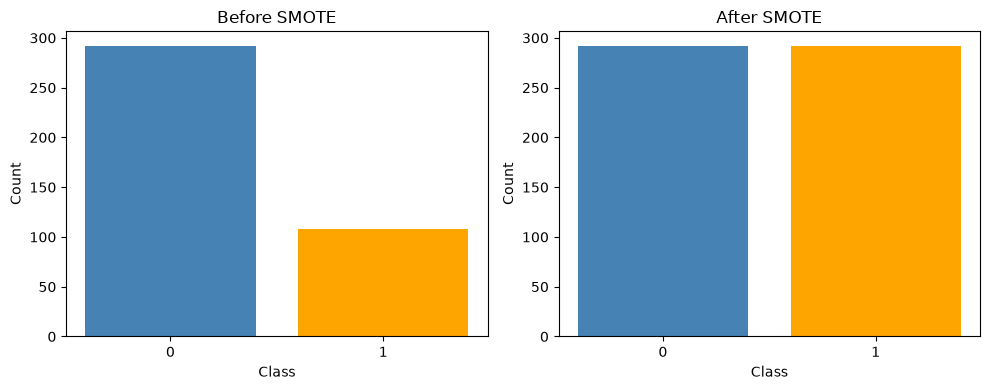

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before_unique, before_counts = np.unique(y_train, return_counts=True)
after_unique, after_counts = np.unique(y_train_smote, return_counts=True)

axes[0].bar(before_unique.astype(str), before_counts, color=['steelblue', 'orange'])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

axes[1].bar(after_unique.astype(str), after_counts, color=['steelblue', 'orange'])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### When do we use RMSE? Is it the same as using MSE? How do you interpret "average error is X units off"?

**MSE (Mean Squared Error)** — average of squared differences between predicted and actual values:

MSE = (1/n) × Σ(yᵢ - ŷᵢ)²

**RMSE (Root Mean Squared Error)** — just the square root of MSE:

RMSE = √MSE

**Not the same, but directly related.** RMSE exists because MSE is in **squared units** (e.g. if predicting price in dollars, MSE is in dollars²), which is hard to interpret. RMSE brings the error back to the **original unit** of the target variable, making it directly comparable to the actual values you're predicting.

**When to use which:**
- **MSE** — useful when optimizing a model mathematically (it's smoother/easier to differentiate for gradient descent), or when you specifically want to penalize large errors more heavily (squaring amplifies big mistakes)
- **RMSE** — the one you'd actually report to a non-technical audience, since it's in interpretable units

**How to interpret an RMSE value (e.g. "3.2 units off"):**
- RMSE is **not literally a plain average error** — it's the square root of the *average squared* error, so large individual errors count disproportionately more than small ones. A model with one huge miss and mostly tiny errors can have the same RMSE as a model that's consistently moderately off.
- **The value is only meaningful relative to the range of your target variable.** RMSE = 3.2 is negligible if your target ranges from 100,000–1,000,000, but massive if your target ranges from 0–10. Always interpret RMSE alongside the scale of what you're predicting, not as a standalone number.
- If you want a metric that's a true plain average (no outlier weighting), use **MAE (Mean Absolute Error)** instead: MAE = (1/n) × Σ|yᵢ - ŷᵢ|. If RMSE is noticeably larger than MAE, that's a signal your model has some large individual errors dragging RMSE up.

**Pipeline stage:** this is an **evaluation metric**, used **after** a model has been trained, to measure regression performance on the test set (or during cross-validation to compare models/hyperparameters).

**Code:** Training a regression model, then computing MSE and RMSE to compare error in squared units vs. original units.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Our y_train/y_test are binary (0/1) from make_classification, so for a
# meaningful regression example we generate a continuous target instead.
# We reuse the same X_train/X_test features but pair them with a new
# continuous y, purely for this regression metric demonstration.
np.random.seed(42)
y_train_reg = X_train @ np.random.rand(X_train.shape[1]) + np.random.normal(0, 1, X_train.shape[0])
y_test_reg = X_test @ np.random.rand(X_test.shape[1]) + np.random.normal(0, 1, X_test.shape[0])

model = LinearRegression()
model.fit(X_train, y_train_reg)
y_pred = model.predict(X_test)

# mean_squared_error computes MSE by default (average of squared errors)
mse = mean_squared_error(y_test_reg, y_pred)

# RMSE is just the square root of MSE — brings error back to original units
rmse = np.sqrt(mse)

print(f"MSE:  {mse:.4f}  (in squared units — hard to interpret directly)")
print(f"RMSE: {rmse:.4f}  (in original units — directly comparable to y values)")

MSE:  3.7640  (in squared units — hard to interpret directly)
RMSE: 1.9401  (in original units — directly comparable to y values)


**Code:** Visualizing predicted vs. actual values, with RMSE noted alongside the ideal prediction line.

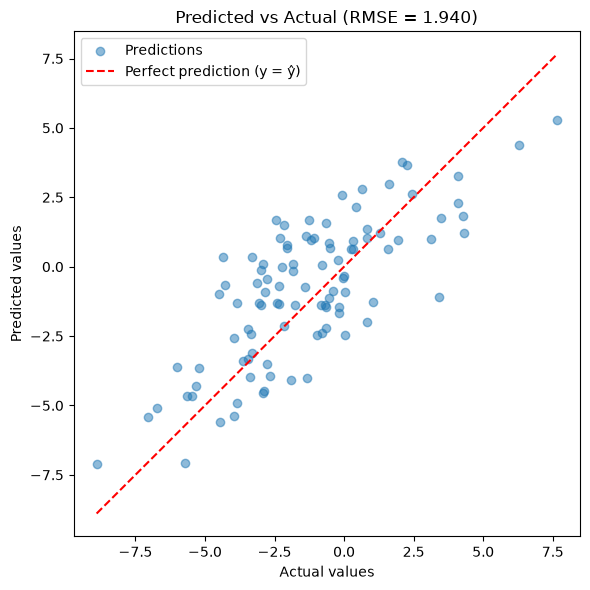

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test_reg, y_pred, alpha=0.5, label='Predictions')

# Perfect prediction line: predicted == actual
lims = [min(y_test_reg.min(), y_pred.min()), max(y_test_reg.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', label='Perfect prediction (y = ŷ)')

ax.set_xlabel('Actual values')
ax.set_ylabel('Predicted values')
ax.set_title(f'Predicted vs Actual (RMSE = {rmse:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

**Code:** Comparing RMSE and MAE on the same predictions — showing how RMSE reacts more strongly to large individual errors, while MAE is a straightforward average.

In [14]:
from sklearn.metrics import mean_absolute_error

# Using the same predictions as before (y_test_reg, y_pred)
mae = mean_absolute_error(y_test_reg, y_pred)      # straightforward average of |error|
# rmse already computed above

print(f"MAE:  {mae:.4f}   ← true average error, in original units")
print(f"RMSE: {rmse:.4f}   ← typical error magnitude, but inflated by any large individual errors")
print(f"\nGap between them (RMSE - MAE = {rmse - mae:.4f}): "
      f"a bigger gap means a few large errors are pulling RMSE up.")

MAE:  1.6441   ← true average error, in original units
RMSE: 1.9401   ← typical error magnitude, but inflated by any large individual errors

Gap between them (RMSE - MAE = 0.2960): a bigger gap means a few large errors are pulling RMSE up.


### What is r-squared, and what is its relevance to ML?

**R² (R-squared / coefficient of determination)** measures the **proportion of variance in the target variable that's explained by the model**, on a scale typically between 0 and 1 (can go negative for a very bad model).

R² = 1 - (SS_res / SS_tot)

Where SS_res (residual sum of squares) is the error your model makes, and SS_tot (total sum of squares) is the error a naive model would make by just predicting the **mean of y** every time.

**How to interpret it:**
- **R² = 1** — model perfectly explains all variance (predictions match actual values exactly)
- **R² = 0** — model does no better than just predicting the mean every time (a naive baseline)
- **R² < 0** — model is worse than that naive mean-prediction baseline
- **R² = 0.75**, for example, means the model explains 75% of the variability in the target; the remaining 25% is unexplained (noise, missing features, model limitations)

**Relevance to ML:** it's a **regression evaluation metric**, complementary to RMSE/MAE. Where RMSE/MAE tell you error in the target's own units, R² tells you **how much better your model is than doing nothing** (i.e. than the naive mean-prediction baseline) — in a unitless, easily comparable 0–1 scale. This makes it easier to compare model quality across different problems/datasets, since it's not tied to the scale of the target variable the way RMSE is.

**Caveat worth knowing:** R² always increases (or stays the same) as you add more features, even useless ones — it doesn't penalize model complexity. **Adjusted R²** corrects for this by penalizing the addition of features that don't meaningfully improve the model — more useful when comparing models with different numbers of features.

**Pipeline stage:** evaluation metric, computed **after** training, on the test set (or during cross-validation).

**Code:** Computing R² for the regression model, and showing the manual calculation to see what's happening under the hood.

In [15]:
from sklearn.metrics import r2_score
import numpy as np

# Using the same regression model/predictions from the RMSE question
r2 = r2_score(y_test_reg, y_pred)

# Manual calculation, to show what's happening under the hood
ss_res = np.sum((y_test_reg - y_pred) ** 2)              # residual sum of squares — model's error
ss_tot = np.sum((y_test_reg - y_test_reg.mean()) ** 2)    # total sum of squares — naive baseline's error
r2_manual = 1 - (ss_res / ss_tot)

print(f"R² (sklearn):  {r2:.4f}")
print(f"R² (manual):   {r2_manual:.4f}")
print(f"\nInterpretation: model explains {r2*100:.1f}% of the variance in the target.")

R² (sklearn):  0.5356
R² (manual):   0.5356

Interpretation: model explains 53.6% of the variance in the target.


**Code:** Comparing model predictions vs. a naive "always predict the mean" baseline, to visualize what R² is actually measuring.

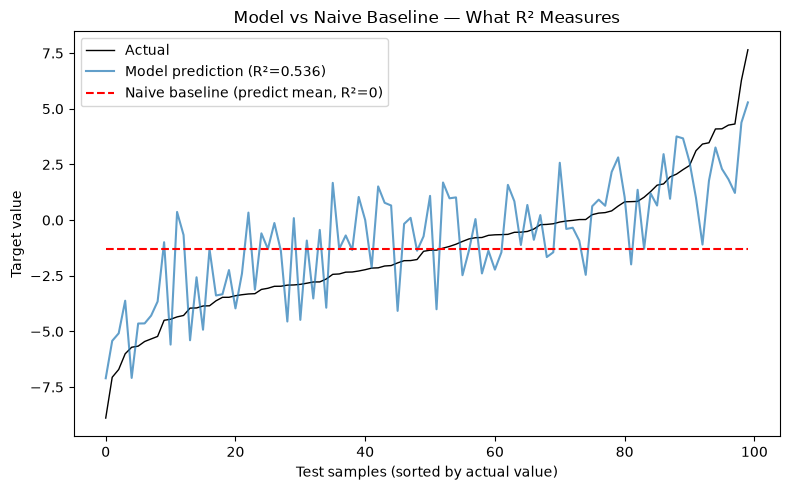

In [16]:
import matplotlib.pyplot as plt

naive_pred = np.full_like(y_test_reg, y_test_reg.mean())  # naive baseline: predict the mean for every sample

fig, ax = plt.subplots(figsize=(8, 5))

# Sort by actual value so the plot reads left-to-right in a sensible order
sort_idx = np.argsort(y_test_reg)

ax.plot(y_test_reg[sort_idx], label='Actual', color='black', linewidth=1)
ax.plot(y_pred[sort_idx], label=f'Model prediction (R²={r2:.3f})', alpha=0.7)
ax.plot(naive_pred[sort_idx], label='Naive baseline (predict mean, R²=0)', linestyle='--', color='red')

ax.set_xlabel('Test samples (sorted by actual value)')
ax.set_ylabel('Target value')
ax.set_title('Model vs Naive Baseline — What R² Measures')
ax.legend()
plt.tight_layout()
plt.show()

### How do we decide between L1 and L2? What does it mean when L1 induces sparsity while L2 regularises weights? Since L2 is better than L1, why bother using L1?

**Quick correction on the premise:** L2 isn't universally "better" than L1 — they solve different problems. The right choice depends on what you need.

**L2 (Ridge) penalty:** adds the sum of *squared* weights to the cost function: λΣw². This shrinks all weights toward zero **smoothly and proportionally**, but rarely forces any weight to exactly 0 — every feature stays in the model, just with a smaller contribution.

**L1 (Lasso) penalty:** adds the sum of *absolute value* of weights: λΣ|w|. Because of the shape of the absolute value function (it has a sharp corner at 0, unlike the smooth curve of w²), the optimizer can actually push some weights all the way to **exactly 0** — effectively removing those features from the model entirely. This is what "**sparsity**" means: a sparse weight vector has many zeros.

**Why L1's sparsity matters — this is the actual reason to use it:**
- **Automatic feature selection.** If you have many features (like SECOM's 591), L1 can automatically tell you which ones matter — the ones with non-zero coefficients — and discard the rest. L2 keeps all 591 features active, just shrunk, which doesn't help you simplify or interpret the model.
- **Interpretability.** A sparse model (say, 20 non-zero weights out of 591) is much easier to explain to Fab leadership than one where all 591 features have small non-zero contributions.
- **Storage/computation.** Fewer active features means a lighter model at inference time.

**Why you'd still use L2 instead:**
- When you believe most/all features are somewhat relevant, and you don't want to discard any (L1 can be too aggressive and drop useful features)
- When features are highly correlated — L1 tends to arbitrarily pick one of several correlated features and zero out the rest, which can be unstable; L2 handles correlated features more gracefully by shrinking them together
- L2 has a smoother, more stable optimization surface, generally easier and faster to converge

**Practical decision rule:**
- Want feature selection / suspect many irrelevant features / need interpretability → **L1**
- Want to keep all features but control overfitting / have correlated features → **L2**
- Want both benefits → **Elastic Net** (combines L1 + L2, with `l1_ratio` controlling the mix)

**Pipeline stage:** regularization is applied **during model training** (it's part of the cost function the optimizer minimizes) — but the *decision* of which to use is a **model selection** choice, typically made during hyperparameter tuning/cross-validation.

**Code:** Comparing L1 (Lasso) and L2 (Ridge) side by side on the same data, showing how many coefficients L1 actually zeroes out vs. L2.

In [17]:
from sklearn.linear_model import Ridge, Lasso
import numpy as np

# Using a moderately strong alpha so the sparsity effect is visible
ridge = Ridge(alpha=5.0)      # L2 — shrinks weights smoothly, rarely hits exactly 0
lasso = Lasso(alpha=0.5, max_iter=10000)  # L1 — can push weights to exactly 0

ridge.fit(X_train, y_train_reg)
lasso.fit(X_train, y_train_reg)

# Count how many coefficients are exactly zero (or very close to it) for each
ridge_zero_count = np.sum(np.abs(ridge.coef_) < 1e-6)
lasso_zero_count = np.sum(np.abs(lasso.coef_) < 1e-6)

print(f"Ridge (L2) — coefficients exactly zero: {ridge_zero_count} / {len(ridge.coef_)}")
print(f"Lasso (L1) — coefficients exactly zero: {lasso_zero_count} / {len(lasso.coef_)}")
print(f"\nRidge coefficients: {np.round(ridge.coef_, 3)}")
print(f"Lasso coefficients: {np.round(lasso.coef_, 3)}")

Ridge (L2) — coefficients exactly zero: 0 / 10
Lasso (L1) — coefficients exactly zero: 3 / 10

Ridge coefficients: [ 0.338  0.665  0.778  0.576 -0.068 -0.187  0.026  0.21   0.025  0.957]
Lasso coefficients: [ 0.017  0.392  0.261  0.584 -0.    -0.12   0.     0.245 -0.     0.468]


**Code:** Visualizing L1 vs L2 coefficient magnitudes as a bar chart — L1's sparsity (bars at exactly 0) should be visibly different from L2's uniform shrinkage.

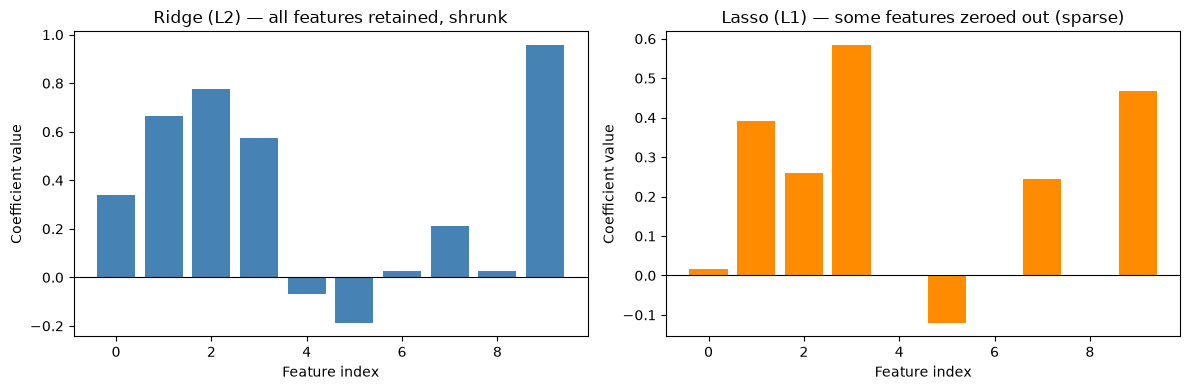

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

feature_idx = np.arange(len(ridge.coef_))  # x-axis: feature index

axes[0].bar(feature_idx, ridge.coef_, color='steelblue')
axes[0].set_title('Ridge (L2) — all features retained, shrunk')
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Coefficient value')
axes[0].axhline(0, color='black', linewidth=0.8)

axes[1].bar(feature_idx, lasso.coef_, color='darkorange')
axes[1].set_title('Lasso (L1) — some features zeroed out (sparse)')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('Coefficient value')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

### Difference between alpha and regularisation?

**Regularisation** is the **technique/concept** — adding a penalty term to the cost function to discourage large weights, in order to reduce overfitting (L1, L2, Elastic Net are types of regularisation).

**Alpha (λ)** is a **hyperparameter** — a single number that controls **how strongly** that regularisation penalty is applied. It's not a technique itself; it's a dial you turn.

**Analogy:** regularisation is like "adding salt to a dish" (the technique/concept). Alpha is "how many teaspoons of salt" (the amount/strength). You can have the concept without a specific alpha value chosen yet, but you can't apply regularisation without alpha being set to *something* (even 0, which means "no regularisation applied").

**What alpha controls specifically:**
- **alpha = 0** → no regularisation effect at all (equivalent to plain Linear/Logistic Regression)
- **Small alpha** → weak penalty, model stays close to an unregularised fit, higher risk of overfitting
- **Large alpha** → strong penalty, weights shrink aggressively toward 0, higher risk of underfitting

**Relationship to bias-variance:** increasing alpha increases bias (simpler model) and decreases variance (less overfitting) — alpha is one of the main levers you tune to move along that tradeoff.

**Naming inconsistency to watch for (you'll hit this in practice):**
- `Ridge`, `Lasso`, `ElasticNet` → parameter is called `alpha`
- `LogisticRegression`, `SVC` → parameter is called `C`, which is the **inverse** of alpha (C = 1/alpha), so smaller `C` = stronger regularisation (opposite direction from `alpha`)

**Pipeline stage:** alpha is a **hyperparameter**, meaning it's not learned by the model automatically during training — you (or a tuning process like `GridSearchCV`/`RidgeCV`/Optuna) choose its value **before or during model selection**, typically via cross-validation, separate from the weights the model learns during fitting.

**Code:** Using cross-validation to find the best alpha value automatically, rather than guessing — showing how alpha is tuned as a hyperparameter, separate from the weights the model learns.

In [19]:
from sklearn.linear_model import RidgeCV
import numpy as np

# RidgeCV automatically tests a range of alpha values using cross-validation
# and picks the one that performs best — this is how alpha is actually
# chosen in practice, rather than picking a number by hand
alphas_to_test = np.logspace(-3, 3, 20)  # 20 candidate alpha values from 0.001 to 1000

ridge_cv = RidgeCV(
    alphas=alphas_to_test,  # the candidate alpha values to try
    cv=5                     # 5-fold cross-validation to evaluate each alpha
)
ridge_cv.fit(X_train, y_train_reg)

print(f"Best alpha found via cross-validation: {ridge_cv.alpha_:.4f}")
print(f"Coefficients at best alpha: {np.round(ridge_cv.coef_, 3)}")

Best alpha found via cross-validation: 0.0010
Coefficients at best alpha: [ 0.343  0.671  0.789  0.578 -0.067 -0.185  0.027  0.209  0.026  0.966]


**Code:** Plotting cross-validated error against different alpha values, showing the classic U-shaped curve — too low alpha overfits, too high alpha underfits, best alpha sits at the minimum.

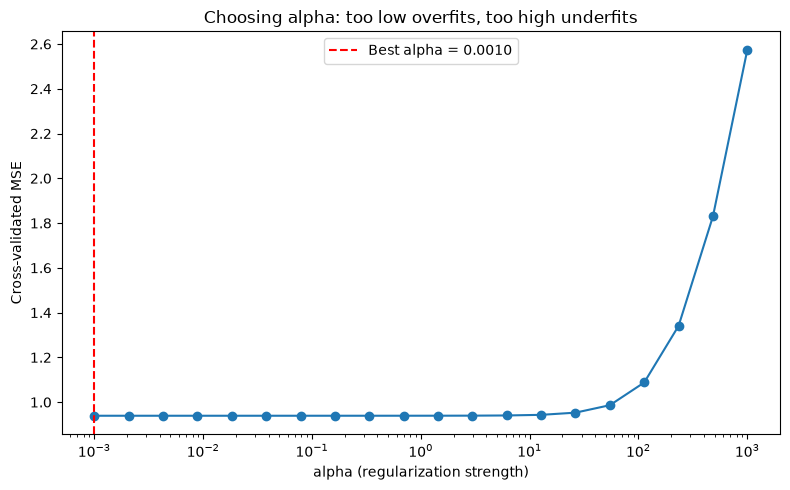

In [20]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

cv_scores = []  # will hold the average cross-validated error for each alpha

for a in alphas_to_test:
    ridge = Ridge(alpha=a)
    # cross_val_score with neg_mean_squared_error — sklearn returns negative MSE by convention
    scores = cross_val_score(ridge, X_train, y_train_reg, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())  # flip sign back to positive MSE for readability

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas_to_test, cv_scores, marker='o')
ax.set_xscale('log')  # log scale since alpha spans several orders of magnitude
ax.axvline(ridge_cv.alpha_, color='red', linestyle='--', label=f'Best alpha = {ridge_cv.alpha_:.4f}')
ax.set_xlabel('alpha (regularization strength)')
ax.set_ylabel('Cross-validated MSE')
ax.set_title('Choosing alpha: too low overfits, too high underfits')
ax.legend()
plt.tight_layout()
plt.show()

### What are other Gradient Descent methods? And when do we use them in ML?

**Gradient Descent (GD)** is the core optimization algorithm that minimizes the cost function by iteratively moving weights in the direction that reduces error, based on the gradient (slope) of the cost function.

**Variants, based on how much data is used per update:**

| Method | How much data per step | Characteristics |
|---|---|---|
| **Batch Gradient Descent** | Entire training set | Stable, accurate gradient, but slow per step — expensive for large datasets |
| **Stochastic Gradient Descent (SGD)** | 1 random sample | Very fast per step, noisy/erratic path to the minimum, can escape shallow local minima, but never fully "settles" |
| **Mini-batch Gradient Descent** | Small batch (e.g. 32, 64, 128 samples) | The practical default — balances speed and stability; standard in almost all real-world training |

**Variants that improve *how* the step is taken — called optimizers, mainly relevant for neural networks:**

- **Momentum** — maintains a "velocity" term: an exponentially weighted moving average of past gradients, instead of reacting only to the current gradient. Intuitively, like a ball with mass rolling downhill — it keeps moving in whatever direction it's been consistently heading, dampening oscillation across narrow valleys in the cost surface and speeding up along the consistent direction.

  Mathematically: v_t = β·v_(t-1) + (1-β)·∇J(w_t), then w_(t+1) = w_t - α·v_t

  In directions where gradients keep flipping sign (oscillating), the exponentially averaged velocity partially cancels these out. In directions where gradients consistently point the same way, they accumulate — so the model speeds up there. Net effect: faster convergence, less wasted zig-zagging.

- **RMSprop** — adapts the learning rate *per parameter*, based on an exponentially weighted average of recent *squared* gradients — giving large steps to parameters with small/infrequent gradients, and small steps to parameters with large/frequent gradients.

- **Adam** (Adaptive Moment Estimation) — combines Momentum (average of past gradients) + RMSprop (average of past squared gradients), with a bias-correction term. The most commonly used optimizer for neural networks in practice.

**When these matter:** not so much about *how many* features you have, but about the **shape of the cost surface** — which depends on feature scale and correlation. Unscaled or correlated features create an elongated, ravine-shaped cost surface, where plain GD oscillates across the narrow direction while creeping slowly along the long one. Momentum/RMSprop/Adam are designed to handle exactly this. Proper feature scaling (covered earlier) already reduces a lot of this problem.

**When to use which:**
- **Batch GD** — small datasets that fit comfortably in memory, when you want the most stable/accurate convergence
- **Mini-batch GD** — the default choice for almost everything, including classical ML with large feature sets (like SECOM) and neural networks
- **SGD** — very large datasets, online/streaming learning
- **Momentum/RMSprop/Adam** — mainly neural network training; sklearn's classical models (`LinearRegression`, `LogisticRegression`, `Ridge`) generally don't use these — they use closed-form solutions or solvers like `lbfgs`/coordinate descent instead

**Relevance to your role:** you'll mainly encounter these directly via `SGDClassifier`/`SGDRegressor`, or if you dip into neural network work later — not something you'll hand-tune day-to-day for classical SECOM-style models.

**Pipeline stage:** gradient descent (and its variants) is part of the **model training** step — the algorithm the optimizer uses internally to fit weights.

**Code:** Implementing gradient descent from scratch on a simple 1-feature regression problem, and visualizing how it converges toward the minimum of the cost function step by step.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Simple 1-feature synthetic data for a clean, visualizable cost surface
np.random.seed(42)
x = np.linspace(0, 10, 50)
y = 3 * x + 7 + np.random.normal(0, 2, size=x.shape)  # true relationship: y = 3x + 7, plus noise

def compute_cost(w, b, x, y):
    # Mean squared error cost function, J(w,b)
    m = len(x)
    predictions = w * x + b
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

def gradient_descent_step(w, b, x, y, learning_rate):
    # Computes the gradient (slope) of the cost function w.r.t. w and b,
    # then takes one step in the opposite direction (downhill)
    m = len(x)
    predictions = w * x + b
    dw = (1 / m) * np.sum((predictions - y) * x)  # partial derivative of cost w.r.t. w
    db = (1 / m) * np.sum(predictions - y)         # partial derivative of cost w.r.t. b
    w_new = w - learning_rate * dw  # step downhill for w
    b_new = b - learning_rate * db  # step downhill for b
    return w_new, b_new

# Initialize weights far from the true values, to make convergence visible
w, b = 0.0, 0.0
learning_rate = 0.01   # step size — too large diverges, too small converges very slowly
n_iterations = 100      # number of gradient descent steps to run

cost_history = []  # track cost at each step, to plot convergence

for i in range(n_iterations):
    cost = compute_cost(w, b, x, y)
    cost_history.append(cost)
    w, b = gradient_descent_step(w, b, x, y, learning_rate)

print(f"Final learned parameters: w={w:.3f}, b={b:.3f} (true values: w=3, b=7)")

Final learned parameters: w=3.646, b=2.039 (true values: w=3, b=7)


import numpy as np
import matplotlib.pyplot as plt

# Simple 1-feature synthetic data for a clean, visualizable cost surface
np.random.seed(42)
x = np.linspace(0, 10, 50)
y = 3 * x + 7 + np.random.normal(0, 2, size=x.shape)  # true relationship: y = 3x + 7, plus noise

def compute_cost(w, b, x, y):
    # Mean squared error cost function, J(w,b)
    m = len(x)
    predictions = w * x + b
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

def gradient_descent_step(w, b, x, y, learning_rate):
    # Computes the gradient (slope) of the cost function w.r.t. w and b,
    # then takes one step in the opposite direction (downhill)
    m = len(x)
    predictions = w * x + b
    dw = (1 / m) * np.sum((predictions - y) * x)  # partial derivative of cost w.r.t. w
    db = (1 / m) * np.sum(predictions - y)         # partial derivative of cost w.r.t. b
    w_new = w - learning_rate * dw  # step downhill for w
    b_new = b - learning_rate * db  # step downhill for b
    return w_new, b_new

# Initialize weights far from the true values, to make convergence visible
w, b = 0.0, 0.0
learning_rate = 0.01   # step size — too large diverges, too small converges very slowly
n_iterations = 100      # number of gradient descent steps to run

cost_history = []  # track cost at each step, to plot convergence

for i in range(n_iterations):
    cost = compute_cost(w, b, x, y)
    cost_history.append(cost)
    w, b = gradient_descent_step(w, b, x, y, learning_rate)

print(f"Final learned parameters: w={w:.3f}, b={b:.3f} (true values: w=3, b=7)")

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Simple 1-feature synthetic data for a clean, visualizable cost surface
np.random.seed(42)
x = np.linspace(0, 10, 50)
y = 3 * x + 7 + np.random.normal(0, 2, size=x.shape)  # true relationship: y = 3x + 7, plus noise

def compute_cost(w, b, x, y):
    # Mean squared error cost function, J(w,b)
    m = len(x)
    predictions = w * x + b
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

def gradient_descent_step(w, b, x, y, learning_rate):
    # Computes the gradient (slope) of the cost function w.r.t. w and b,
    # then takes one step in the opposite direction (downhill)
    m = len(x)
    predictions = w * x + b
    dw = (1 / m) * np.sum((predictions - y) * x)  # partial derivative of cost w.r.t. w
    db = (1 / m) * np.sum(predictions - y)         # partial derivative of cost w.r.t. b
    w_new = w - learning_rate * dw  # step downhill for w
    b_new = b - learning_rate * db  # step downhill for b
    return w_new, b_new

# Initialize weights far from the true values, to make convergence visible
w, b = 0.0, 0.0
learning_rate = 0.01   # step size — too large diverges, too small converges very slowly
n_iterations = 100      # number of gradient descent steps to run

cost_history = []  # track cost at each step, to plot convergence

for i in range(n_iterations):
    cost = compute_cost(w, b, x, y)
    cost_history.append(cost)
    w, b = gradient_descent_step(w, b, x, y, learning_rate)

print(f"Final learned parameters: w={w:.3f}, b={b:.3f} (true values: w=3, b=7)")

Final learned parameters: w=3.646, b=2.039 (true values: w=3, b=7)


**Code:** Plotting the cost function value at each iteration — this is the "descent" in gradient descent, visually showing convergence toward the minimum.

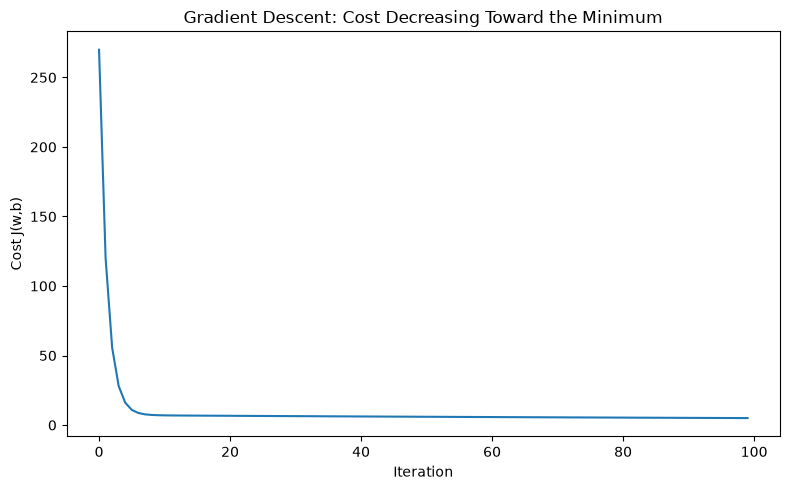

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(n_iterations), cost_history)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost J(w,b)')
ax.set_title('Gradient Descent: Cost Decreasing Toward the Minimum')
plt.tight_layout()
plt.show()

**Code:** Comparing Batch, Mini-batch, and Stochastic Gradient Descent paths using sklearn's SGDRegressor, to see the practical difference in convergence behaviour.

In [24]:
from sklearn.linear_model import SGDRegressor

# SGDRegressor performs stochastic/mini-batch gradient descent under the hood
sgd = SGDRegressor(
    max_iter=1000,       # maximum number of passes over the training data (epochs)
    learning_rate='constant',  # keep the learning rate fixed, rather than decaying it over time
    eta0=0.01,            # the (constant) learning rate value
    random_state=42       # reproducibility — SGD's randomness in sample order affects the result
)

# reshape needed: SGDRegressor expects 2D input (n_samples, n_features), x here is 1D
sgd.fit(x.reshape(-1, 1), y)

print(f"SGDRegressor learned: w={sgd.coef_[0]:.3f}, b={sgd.intercept_[0]:.3f}")

SGDRegressor learned: w=2.932, b=6.896


**Code:** Comparing plain Gradient Descent vs Momentum on a deliberately elongated ("ravine-shaped") cost surface — this is where Momentum's advantage becomes visually obvious: plain GD zig-zags across the narrow direction, Momentum smooths that out and moves more directly toward the minimum.

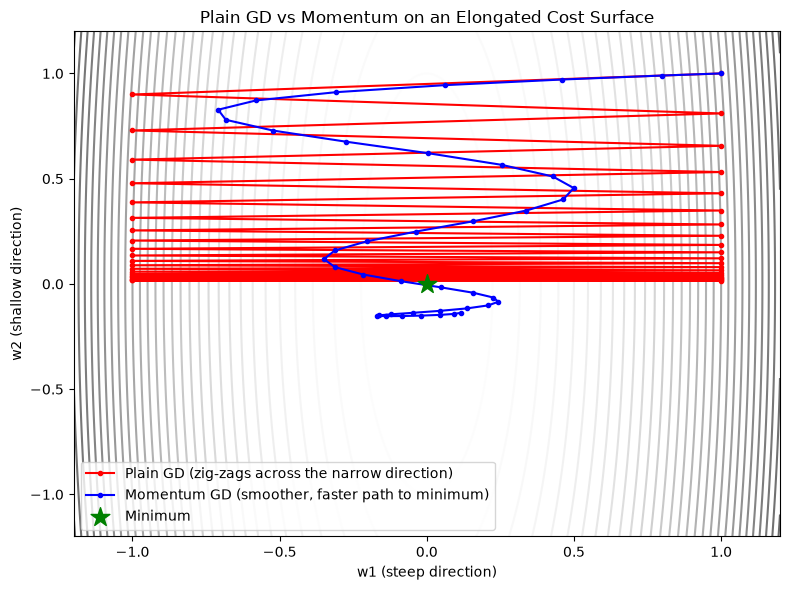

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Elongated quadratic cost function: steep in one direction, shallow in the other
# J(w1, w2) = a*w1^2 + b*w2^2, with a >> b creates a ravine shape
a, b = 20, 1

def cost_2d(w1, w2):
    return a * w1**2 + b * w2**2

def gradient_2d(w1, w2):
    # partial derivatives: dJ/dw1 = 2*a*w1, dJ/dw2 = 2*b*w2
    return np.array([2 * a * w1, 2 * b * w2])

def plain_gd(start, learning_rate, n_steps):
    # Standard gradient descent — reacts only to the current gradient each step
    w = np.array(start, dtype=float)
    path = [w.copy()]
    for _ in range(n_steps):
        grad = gradient_2d(*w)
        w = w - learning_rate * grad
        path.append(w.copy())
    return np.array(path)

def momentum_gd(start, learning_rate, n_steps, beta=0.9):
    # Gradient descent with momentum — maintains a velocity term (exponentially
    # weighted average of past gradients) instead of reacting only to the current step
    w = np.array(start, dtype=float)
    velocity = np.zeros_like(w)  # v_0 = 0, no history yet
    path = [w.copy()]
    for _ in range(n_steps):
        grad = gradient_2d(*w)
        velocity = beta * velocity + (1 - beta) * grad  # blend past velocity with current gradient
        w = w - learning_rate * velocity                 # step using the smoothed velocity, not raw gradient
        path.append(w.copy())
    return np.array(path)

start_point = [1.0, 1.0]     # both start at the same point
lr = 0.05                     # same learning rate for a fair comparison
steps = 40

path_plain = plain_gd(start_point, lr, steps)
path_momentum = momentum_gd(start_point, lr, steps)

# Build contour plot of the cost surface to visualize the "ravine"
w1_range = np.linspace(-1.2, 1.2, 200)
w2_range = np.linspace(-1.2, 1.2, 200)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = cost_2d(W1, W2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(W1, W2, Z, levels=30, cmap='Greys', alpha=0.6)  # contour lines of the cost surface

ax.plot(path_plain[:, 0], path_plain[:, 1], 'o-', color='red', markersize=3,
        label='Plain GD (zig-zags across the narrow direction)')
ax.plot(path_momentum[:, 0], path_momentum[:, 1], 'o-', color='blue', markersize=3,
        label='Momentum GD (smoother, faster path to minimum)')
ax.scatter(0, 0, color='green', marker='*', s=200, label='Minimum', zorder=5)

ax.set_xlabel('w1 (steep direction)')
ax.set_ylabel('w2 (shallow direction)')
ax.set_title('Plain GD vs Momentum on an Elongated Cost Surface')
ax.legend()
plt.tight_layout()
plt.show()

**Reading a learning curve (train error vs. CV error as training size grows):** a persistent, large gap between training error (low) and CV error (high) that doesn't close as training size grows is the signature of **high variance**. If instead both curves converge to a similarly *high* error early on, that signals **high bias** — more data wouldn't help, but a more complex model would.

### Explain SVM thoroughly

**Support Vector Machine (SVM)** is a classification (and regression, via SVR) algorithm that finds the **best boundary (hyperplane)** separating classes by **maximizing the margin** — the distance between the boundary and the nearest points of each class.

**Core concepts:**

**1. The hyperplane** — the decision boundary. In 2D it's a line, in 3D a plane, in higher dimensions a hyperplane. For binary classification: w·x + b = 0.

**2. The margin** — the gap between the hyperplane and the closest data points from each class. SVM doesn't just find *any* separating line — it finds the one that **maximizes this margin**, because a wider margin generally generalizes better to unseen data.

**3. Support vectors** — the data points closest to the hyperplane, that actually "support" (define) where the margin boundary sits. These are the only points that matter for the decision boundary — points far from the boundary have zero influence on it, which is a distinctive property vs. other classifiers (like logistic regression, which uses all points).

**4. Hard margin vs. soft margin:**
- **Hard margin** — requires perfect separation, no points allowed inside the margin. Only works if data is perfectly linearly separable, which is rare/fragile in practice (very sensitive to outliers)
- **Soft margin** — allows some points to violate the margin (or even be misclassified), controlled by a penalty. This is what's used in practice. The `C` parameter controls the trade-off: large `C` = less tolerance for margin violations (narrower margin, risk of overfitting); small `C` = more tolerance (wider margin, risk of underfitting)

**5. The kernel trick — handling non-linear boundaries:**
Many real datasets aren't linearly separable. SVM handles this via **kernels** — functions that implicitly map data into a higher-dimensional space where a linear boundary *can* separate the classes, without actually computing that transformation explicitly (which would be computationally expensive). Common kernels:
- **Linear** — no transformation, straight-line/hyperplane boundary
- **Polynomial** — captures polynomial relationships between features
- **RBF (Radial Basis Function / Gaussian)** — the most commonly used non-linear kernel; creates flexible, curved boundaries. Controlled by `gamma` — high gamma = boundary hugs individual points closely (risk of overfitting), low gamma = smoother, more generalized boundary

**Relevance to your role:** SVM is a solid classical ML algorithm for classification tasks like SECOM pass/fail prediction, especially useful when you have complex/non-linear boundaries and moderate-sized datasets. It doesn't scale as well as tree-based methods (Random Forest/XGBoost) to very large datasets or very high feature counts (591 features + 1567 samples is borderline — feasible, but worth benchmarking against tree-based models on training time).

**Pipeline stage:** SVM is a **model** — you choose it during **model selection**, then it's fit during **training**. Kernel choice and hyperparameters (`C`, `gamma`, `kernel`) are tuned during **hyperparameter tuning** (cross-validation/GridSearchCV/Optuna), same stage as any other model.

**Code:** Fitting a linear SVM and an RBF-kernel SVM on 2D data, and visualizing their decision boundaries and support vectors side by side — this makes the margin and support vector concepts visually concrete.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons  # generates a non-linearly-separable 2-class dataset, good for showing kernel benefit

# make_moons creates two interleaving crescent shapes — cannot be separated by a straight line,
# a good demonstration of why the RBF kernel is needed for non-linear boundaries
X_svm, y_svm = make_moons(
    n_samples=200,   # number of points to generate
    noise=0.15,       # amount of random noise added — makes the boundary between classes fuzzier/more realistic
    random_state=42
)

# Linear SVM — will struggle since this data isn't linearly separable
svm_linear = SVC(
    kernel='linear',  # no transformation — straight-line decision boundary
    C=1.0              # regularization: how much to penalize margin violations
)
svm_linear.fit(X_svm, y_svm)

# RBF SVM — can capture the curved boundary needed here
svm_rbf = SVC(
    kernel='rbf',    # Gaussian kernel — maps to higher-dimensional space implicitly
    C=1.0,             # same role as above
    gamma='scale'      # kernel coefficient — 'scale' auto-computes based on feature variance, a sensible default
)
svm_rbf.fit(X_svm, y_svm)

print(f"Linear SVM accuracy: {svm_linear.score(X_svm, y_svm):.3f}")
print(f"RBF SVM accuracy:    {svm_rbf.score(X_svm, y_svm):.3f}")
print(f"\nNumber of support vectors (linear): {svm_linear.n_support_}")
print(f"Number of support vectors (RBF):    {svm_rbf.n_support_}")

Linear SVM accuracy: 0.845
RBF SVM accuracy:    0.980

Number of support vectors (linear): [35 35]
Number of support vectors (RBF):    [23 23]


**Code:** Plotting the decision boundary and highlighting the support vectors for both models — showing why the linear kernel fails on this data, and how the RBF kernel curves around it correctly.

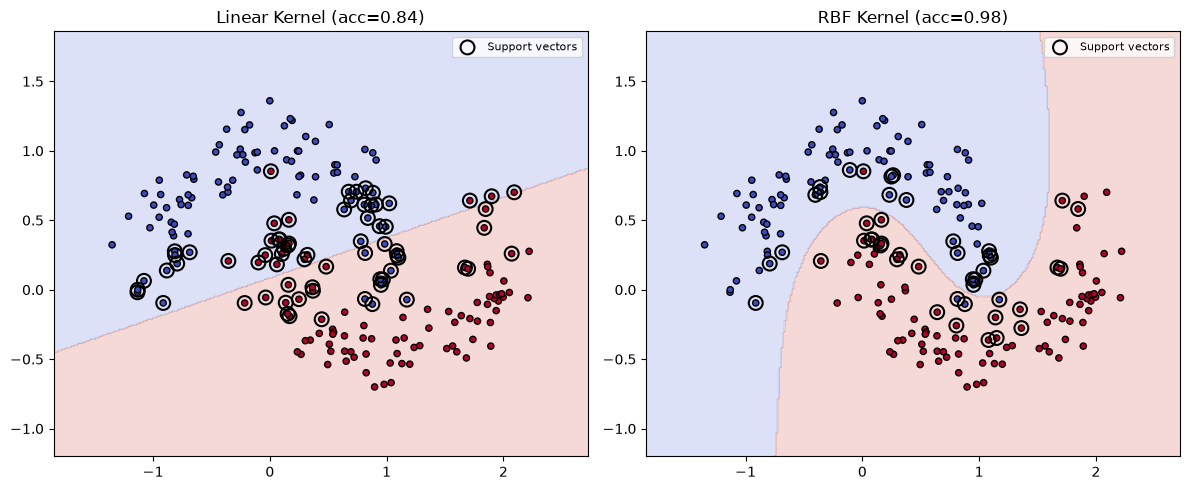

In [27]:
def plot_svm_boundary(ax, model, X, y, title):
    # Build a fine grid covering the data range, to evaluate the model at every point
    # and draw a filled contour showing the predicted region for each class
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])  # predict class for every point on the grid
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')  # shaded regions = predicted class areas
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20)

    # Circle the support vectors specifically — the points that define the margin
    ax.scatter(
        model.support_vectors_[:, 0], model.support_vectors_[:, 1],
        s=100, facecolors='none', edgecolors='black', linewidths=1.5,
        label='Support vectors'
    )
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_svm_boundary(axes[0], svm_linear, X_svm, y_svm, f'Linear Kernel (acc={svm_linear.score(X_svm, y_svm):.2f})')
plot_svm_boundary(axes[1], svm_rbf, X_svm, y_svm, f'RBF Kernel (acc={svm_rbf.score(X_svm, y_svm):.2f})')
plt.tight_layout()
plt.show()

**Code:** Comparing the effect of the `C` parameter on the SVM's margin width — low C allows a wider margin with more violations, high C forces a narrower, stricter margin.

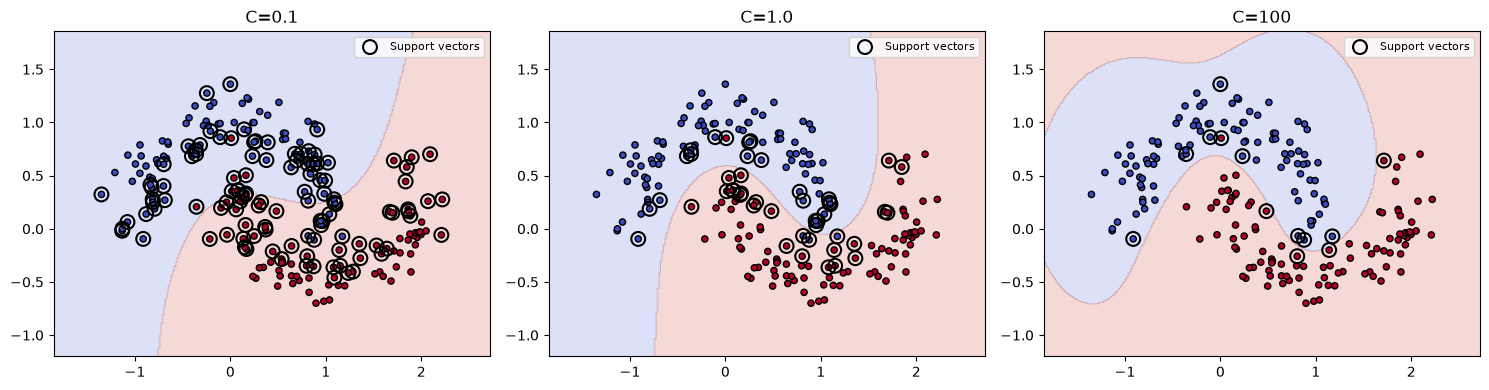

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
C_values = [0.1, 1.0, 100]  # low, medium, high regularization strength

for ax, c_val in zip(axes, C_values):
    svm_c = SVC(kernel='rbf', C=c_val, gamma='scale')
    svm_c.fit(X_svm, y_svm)
    plot_svm_boundary(ax, svm_c, X_svm, y_svm, f'C={c_val}')

plt.tight_layout()
plt.show()

# 2. Advanced Learning Algorithms (Course 2)

### When and how do we use bias and variance in ML?

**Bias** = error from a model being too simple to capture the underlying pattern (underfitting). **Variance** = error from a model being too sensitive to the training data, capturing noise instead of signal (overfitting).

**When you use this concept:** any time you're diagnosing why a model performs poorly, and deciding what to fix — it's the standard diagnostic framework for improving model performance.

**How you diagnose it — compare training error vs. cross-validation (dev) error:**
- **High bias (underfitting):** both training error and CV error are high, and close to each other — the model isn't even fitting the training data well
- **High variance (overfitting):** training error is low, but CV error is much higher than training error — the model memorized the training data but doesn't generalize

**How you fix each:**

| Problem | Fixes |
|---|---|
| High bias | Add more features, use a more complex model, reduce regularization (lower alpha), train longer |
| High variance | Get more training data, reduce number of features, increase regularization (higher alpha), simplify the model |

**Rule of thumb:** if adding more data doesn't help, you likely have a bias problem, not a variance problem — more data only fixes variance, since a model that's fundamentally too simple won't improve no matter how much data you throw at it.

**Connection to earlier questions:** this directly ties to alpha/regularization (higher alpha → more bias, less variance) and to polynomial degree/model complexity in general — bias-variance is the underlying tradeoff that regularization, feature selection, and model complexity are all levers for.

**Pipeline stage:** this is a **model evaluation / diagnosis** step, done **after** training a model (often across multiple models or hyperparameter settings during cross-validation), to decide what to adjust before finalizing a model.

**Code:** Generating three models of different complexity (underfit, good fit, overfit) on the same data, and visualizing how each fits the training points differently.

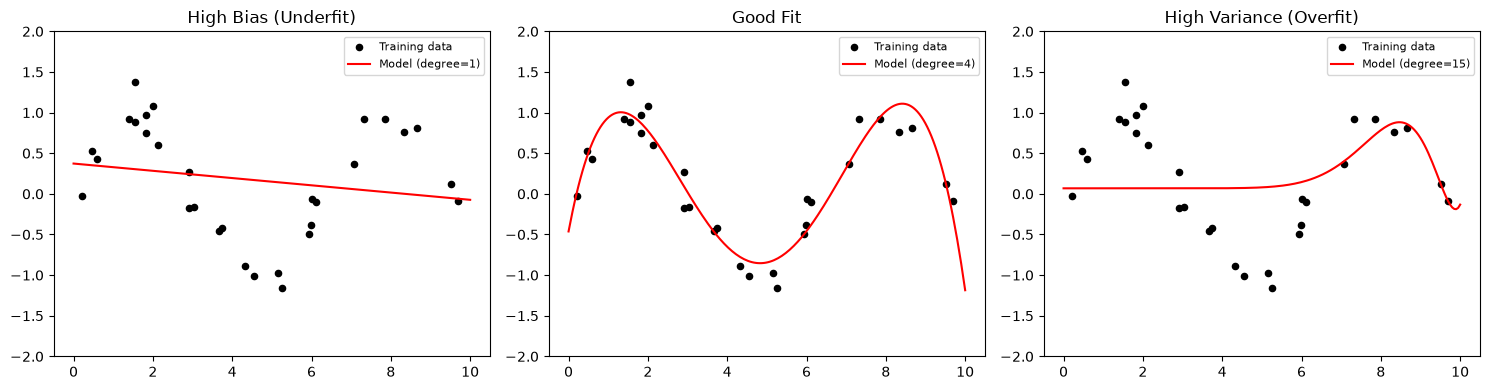

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Generate a simple 1D nonlinear dataset — true relationship is a sine wave, plus noise
np.random.seed(42)
x_bv = np.sort(np.random.uniform(0, 10, 30)).reshape(-1, 1)  # 30 points, sorted for clean plotting
y_bv = np.sin(x_bv).ravel() + np.random.normal(0, 0.2, x_bv.shape[0])  # true pattern + noise

# Three models of increasing complexity, via polynomial degree
degrees = {
    'High Bias (Underfit)': 1,    # degree 1 = straight line, too simple for a sine wave
    'Good Fit': 4,                  # degree 4 = flexible enough to capture the sine pattern
    'High Variance (Overfit)': 15   # degree 15 = way too flexible, will chase noise
}

x_smooth = np.linspace(0, 10, 200).reshape(-1, 1)  # dense x values, for drawing smooth prediction curves

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, degree) in zip(axes, degrees.items()):
    # make_pipeline chains PolynomialFeatures (creates x, x^2, x^3... columns)
    # with LinearRegression (fits weights on those expanded features)
    model = make_pipeline(
        PolynomialFeatures(degree=degree),  # degree = how many polynomial terms to generate
        LinearRegression()
    )
    model.fit(x_bv, y_bv)
    y_smooth_pred = model.predict(x_smooth)

    ax.scatter(x_bv, y_bv, color='black', s=20, label='Training data')
    ax.plot(x_smooth, y_smooth_pred, color='red', label=f'Model (degree={degree})')
    ax.set_title(label)
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Code:** Plotting a learning curve — training error vs. cross-validation error as training set size increases — the classic diagnostic tool for telling bias and variance problems apart.

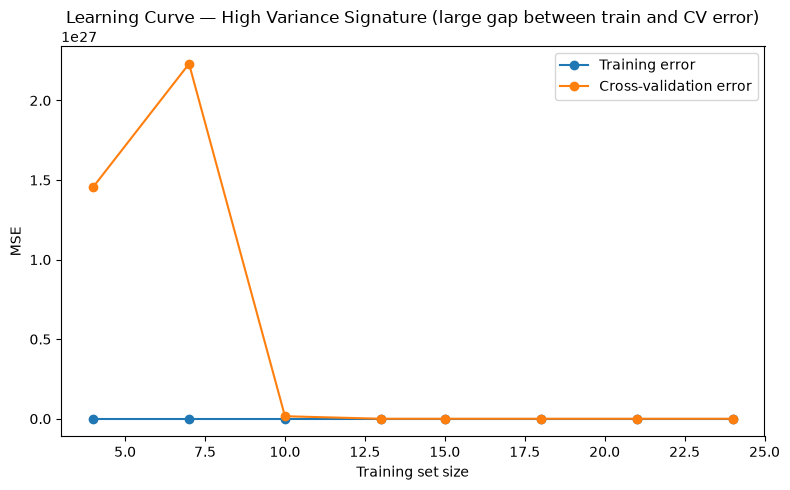

In [30]:
from sklearn.model_selection import learning_curve

# learning_curve trains the model on increasing subset sizes of the training
# data, and records train/CV error at each size — used to diagnose bias vs variance
model_overfit = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())

train_sizes, train_scores, val_scores = learning_curve(
    model_overfit,
    x_bv, y_bv,
    train_sizes=np.linspace(0.2, 1.0, 8),  # use 20%, 34%, ..., 100% of training data at each step
    cv=5,                                    # 5-fold cross-validation at each training size
    scoring='neg_mean_squared_error'         # sklearn convention: negative MSE (higher = better)
)

# Convert negative MSE back to positive, and average across the 5 folds
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_errors, 'o-', label='Training error')
ax.plot(train_sizes, val_errors, 'o-', label='Cross-validation error')
ax.set_xlabel('Training set size')
ax.set_ylabel('MSE')
ax.set_title('Learning Curve — High Variance Signature (large gap between train and CV error)')
ax.legend()
plt.tight_layout()
plt.show()

### Where do we use transfer learning?

**Transfer learning** takes a model already trained on one task (usually on a large dataset) and **reuses part of it** as the starting point for a new, related task — instead of training a new model completely from scratch.

**Note on scope:** this is a **neural network** concept (Ng covers it in Course 2, Week 2 — Neural Network Training). It's genuinely outside your day-1 role scope (classical ML, not deep learning), but since it's in your question list, here's the full explanation.

**How it works, conceptually:**
- A neural network's early layers tend to learn **general-purpose features** (e.g. in image models: edges, textures, shapes). Later layers learn **task-specific features** (e.g. "this pattern means cat vs. dog").
- Transfer learning **keeps and reuses the early layers** (which already learned useful general patterns from a large dataset), and **retrains only the later layers** on your smaller, specific dataset.
- This works because those general features are often *transferable* across related tasks, even if the final task is different.

**Two common strategies:**
- **Feature extraction** — freeze all the pretrained layers (don't update their weights at all), only train a new final layer on top for your specific task. Fast, works well when your dataset is small.
- **Fine-tuning** — unfreeze some (usually the later) pretrained layers and continue training them, at a low learning rate, alongside the new final layer. Allows the model to adapt more to your specific task, but needs more data to avoid overfitting.

**When to use it:**
- Your dataset is **small** — training a large neural network from scratch on limited data leads to severe overfitting; transfer learning lets you benefit from a much larger dataset the base model was trained on
- Your task is **similar** to the one the base model was trained on (e.g. reusing an ImageNet-trained model for a different image classification task)
- You want to **save training time/compute** — reusing pretrained weights converges much faster than starting from random initialization

**When it's NOT applicable to your role:** classical ML models (linear/logistic regression, Random Forest, XGBoost, SVM) don't have "layers" in this sense — there's no direct equivalent of transfer learning for them. This is specifically a deep learning technique.

**Note — "knowledge transfer" is the same concept:** the question "when do we do knowledge transfer for ML, and how do we code it" is asking about the same technique described above under a different name. Transfer learning IS the mechanism of transferring learned knowledge from one model/task to another — there isn't a separate distinct technique called "knowledge transfer" in standard ML terminology. (Note: this differs from "knowledge distillation," a related but distinct technique where a smaller "student" model is trained to mimic a larger "teacher" model's outputs — worth knowing the name exists, but it's a different concept from transfer learning.)

**Pipeline stage:** transfer learning affects the **model architecture / training** stage — specifically how you initialize and train a model, before evaluation.

**Code:** Full runnable transfer learning example — downloading a small public flower image dataset, loading it into train/validation sets, then applying the frozen-base + new-head pattern from before.

In [31]:
import tensorflow as tf
import pathlib

# Downloads a small (~3,600 image) flower photos dataset — standard Keras tutorial dataset,
# good for a quick, real, runnable transfer learning example
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(
    'flower_photos',       # local folder name to save it under
    origin=dataset_url,     # URL to download from
    untar=True               # automatically extract the downloaded .tgz archive
)
data_dir = pathlib.Path(data_dir)

image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"Total images downloaded: {image_count}")
print(f"Classes: {[d.name for d in data_dir.iterdir() if d.is_dir()]}")

Total images downloaded: 0
Classes: ['flower_photos']


**Code:** Building train/validation datasets from the downloaded images — `image_dataset_from_directory` automatically infers class labels from the folder structure and handles batching/resizing.

In [32]:
img_size = (160, 160)  # must match the input_shape used by the base model
batch_size = 32

# image_dataset_from_directory automatically infers class labels from subfolder names,
# and handles batching/resizing for you
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,   # reserve 20% of images for validation
    subset='training',       # this call returns the training portion
    seed=42,                 # ensures the same train/val split every time you rerun
    image_size=img_size,     # resize all images to this size
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',     # this call returns the validation portion (the other 20%)
    seed=42,                 # SAME seed as above, so train/val splits don't overlap
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
Classes found: ['flower_photos']


**Code:** Building the transfer learning model — a frozen pretrained MobileNetV2 base (feature extractor) with a new trainable classification head on top, adapted for this dataset's 5 flower classes.

In [33]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze — feature extraction strategy

# Preprocessing layer specific to MobileNetV2 — pretrained models expect
# pixel values scaled a specific way, matching how they were originally trained
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1),  # matches MobileNetV2's expected [-1, 1] pixel range
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')  # softmax for multi-class (5 flower types), not sigmoid
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # matches integer class labels from image_dataset_from_directory
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

**Code:** Training the model — since the base is frozen, only the new classification head's weights get updated during this run.

In [34]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5   # kept low for a quick first run — increase once you confirm it works end-to-end
)

Epoch 1/5


/opt/anaconda3/envs/dsprint/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
/opt/anaconda3/envs/dsprint/lib/python3.11/site-packages/keras/src/ops/nn.py:959: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00


**Code:** Plotting training vs validation accuracy over epochs, to check the model is actually learning and not overfitting.

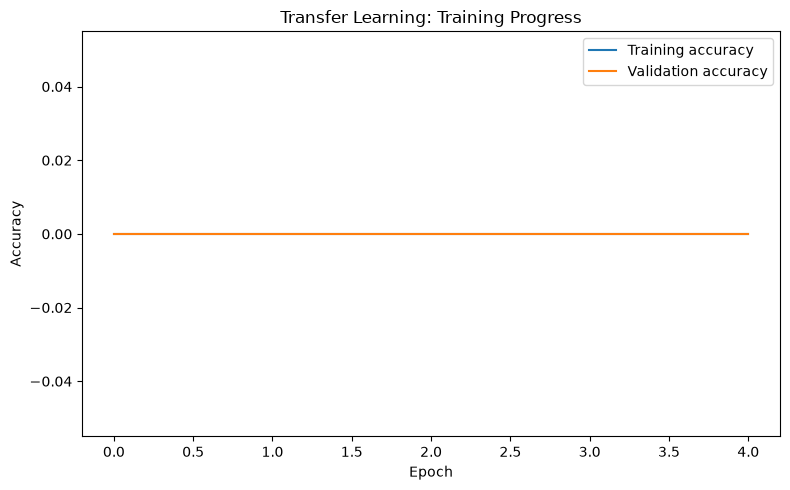

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Loss per epoch: [0.0, 0.0, 0.0, 0.0, 0.0]
Val loss per epoch: [0.0, 0.0, 0.0, 0.0, 0.0]


In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['accuracy'], label='Training accuracy')
ax.plot(history.history['val_accuracy'], label='Validation accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Transfer Learning: Training Progress')
ax.legend()
plt.tight_layout()
plt.show()

print(history.history.keys())
print("Loss per epoch:", history.history['loss'])
print("Val loss per epoch:", history.history['val_loss'])

# 3: Unsupervised Learning, Recommenders, Reinforcement Learning (Course 3)

### How does the transformation of data for PCA help in ML? Which step does PCA come in when performing ML?

**PCA (Principal Component Analysis)** is a **dimensionality reduction** technique — it transforms a dataset with many (possibly correlated) features into a smaller set of new, uncorrelated features called **principal components**, while preserving as much of the original variance (information) as possible.

**How the transformation works, intuitively:**
- PCA finds new axes (directions in feature space) that capture the most variance in the data — the **first principal component** is the direction of maximum variance, the **second** is the direction of the next-most variance, *orthogonal* (perpendicular) to the first, and so on
- Each original data point gets **re-expressed** in terms of these new axes instead of the original features
- You then keep only the top few components (that explain most of the variance) and discard the rest — this is where the dimensionality reduction happens

**Why this transformation helps in ML:**
- **Reduces feature count** without losing much information — critical when you have far more features than makes sense (e.g. SECOM's 591 features), since many features are often correlated/redundant
- **Speeds up training** — fewer features means faster fitting, especially for algorithms that scale poorly with feature count
- **Reduces overfitting risk** — fewer, less redundant features means less chance the model latches onto noise from irrelevant/correlated features
- **Removes multicollinearity** — since principal components are mathematically uncorrelated with each other, this helps algorithms (like linear regression) that assume/perform better with independent features
- **Enables visualization** — reducing to 2-3 components lets you plot high-dimensional data to visually spot clusters or patterns that would be invisible in 591-dimensional space

**Important tradeoff:** PCA components are combinations of original features (linear combinations), so you **lose direct interpretability** — "Principal Component 1" doesn't map to a single physical sensor reading anymore, it's a weighted blend of many. This matters for explaining results to Fab leadership — PCA is great for modeling, but you often need to trace back to original features (e.g. via loadings) for domain interpretation.

**Where PCA sits in the ML pipeline:** it's a **preprocessing / dimensionality reduction step**, applied:
1. **After** train/test split (fit PCA on train only, to avoid leakage)
2. **After** scaling/standardisation (PCA is highly sensitive to feature scale — unscaled features with larger raw ranges will dominate the variance calculation and distort the components)
3. **Before** model training

Raw data → Train/test split → Scale (StandardScaler) → PCA (fit on train, transform both) → Train model → Evaluate

**Practical note for SECOM:** with 591 features, PCA (or a variant like `IncrementalPCA` for memory efficiency) is a very natural fit — you'd typically use a cumulative variance plot to decide how many components retain, say, 90-95% of the variance, drastically cutting feature count while keeping most of the signal.

**Code:** Applying PCA to reduce our 10-feature dataset down to 2 components, and checking how much variance is retained — this shows the core tradeoff PCA makes between dimensionality reduction and information loss.

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# PCA is scale-sensitive, so we standardise first — reusing the scaler pattern from earlier
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test using train's mean/std

# PCA reduces dimensionality by projecting onto the directions of maximum variance
pca = PCA(
    n_components=2,     # how many principal components to keep — reducing from 10 features down to 2
    random_state=42      # PCA's internal SVD solver can have minor randomness depending on solver choice
)

X_train_pca = pca.fit_transform(X_train_scaled)  # learns the components from train, and transforms it
X_test_pca = pca.transform(X_test_scaled)         # applies the SAME learned components to test data

print(f"Original shape: {X_train_scaled.shape}")
print(f"After PCA shape: {X_train_pca.shape}")
print(f"\nVariance explained by each component: {pca.explained_variance_ratio_}")
print(f"Total variance retained with 2 components: {pca.explained_variance_ratio_.sum():.2%}")

Original shape: (400, 10)
After PCA shape: (400, 2)

Variance explained by each component: [0.25389567 0.19052735]
Total variance retained with 2 components: 44.44%


**Code:** Plotting a scree plot (variance explained vs. number of components) — the standard way to decide how many components to keep, by finding where additional components stop adding much value ("the elbow").

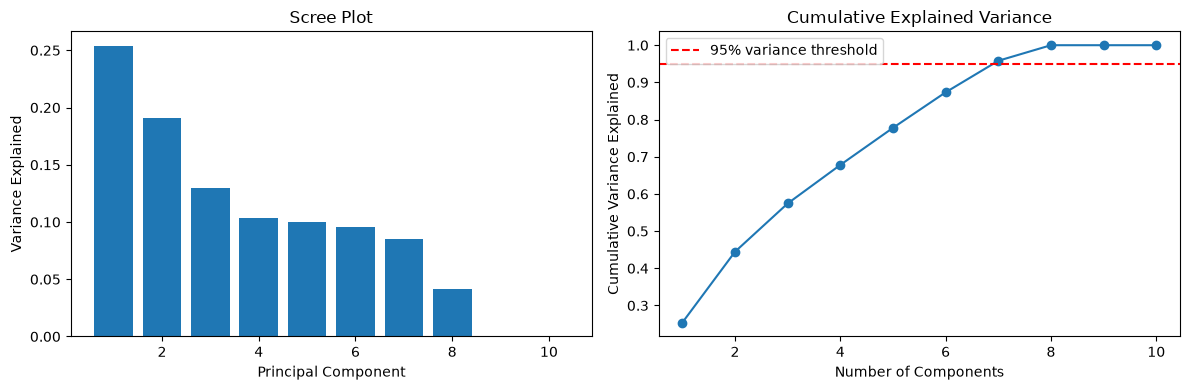

In [37]:
import matplotlib.pyplot as plt

# Fit PCA keeping ALL components, just to see the full variance breakdown
pca_full = PCA(n_components=None)  # None = keep all components (same count as original features)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)  # running total of variance explained

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot — variance explained by each individual component
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')

# Cumulative variance — helps decide how many components to keep (e.g. for 95% variance retained)
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
axes[1].axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

**Code:** Visualizing the dataset in 2D using the first two principal components, colored by class — a common use of PCA for exploratory data analysis (EDA), letting you visually check for class separation before modeling.

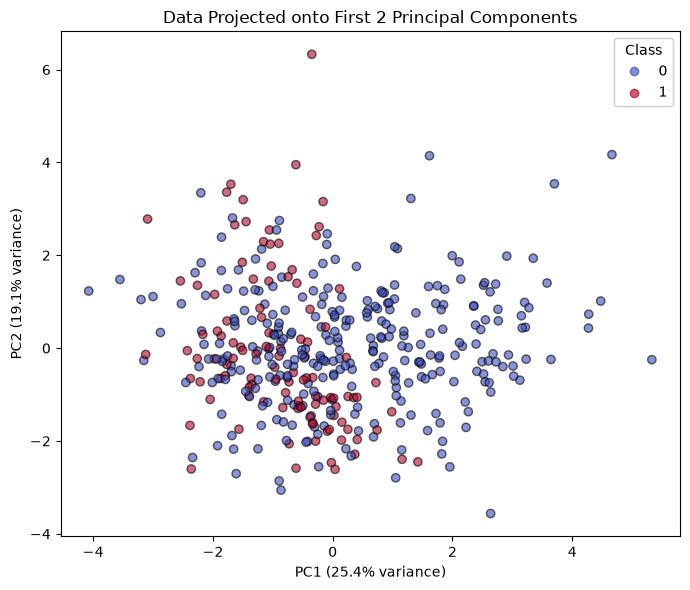

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Data Projected onto First 2 Principal Components')
legend1 = ax.legend(*scatter.legend_elements(), title="Class")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

### How to perform anomaly detection in ML programming?

**Anomaly detection** identifies data points that deviate significantly from the "normal" pattern in a dataset — used when you're looking for **rare, unusual events** (defects, fraud, equipment failures) rather than classifying between roughly-balanced categories.

**How it differs from oversampling/classification for imbalanced data:** oversampling still trains a *supervised* classifier that learns from labeled examples of both classes. Anomaly detection is often used when you have **very few or no labeled anomaly examples** — instead, you model what "normal" looks like, then flag anything that doesn't fit that model. This makes it well suited to problems where failures are rare enough that you can't reliably train a classifier on them.

**Main approaches Ng covers (Course 3, Week 1):**

**1. Gaussian (Normal Distribution) Anomaly Detection:**
- Assumes each feature follows a normal distribution when the process is "normal"
- Fits a Gaussian distribution (mean, variance) to each feature using only normal-example training data
- For a new point, computes the probability p(x) under that fitted distribution — if p(x) is below some threshold epsilon, flag it as an anomaly
- Intuition: points far from the mean, in low-density regions of the distribution, are unusual

**2. Isolation Forest** (not in Ng's Specialization, but a standard practical tool):
- Builds random decision trees that isolate points by random splits
- Anomalies are **easier to isolate** (fewer splits needed to separate them from the rest), since they sit in sparse regions of the feature space — this gives an "anomaly score" based on average isolation depth across many trees

**When to use which:**
- **Gaussian method** — simple, interpretable, works well when features are roughly normally distributed and you understand what "normal" looks like feature-by-feature
- **Isolation Forest** — doesn't assume any particular distribution shape, handles multi-dimensional interactions better, generally the more practical default for real-world tabular data

**Anomaly detection vs. supervised classification — when to pick which (Ng's guidance):**
- **Anomaly detection**: very few positive (anomaly) examples (0-20), many different "types" of anomalies that future anomalies may not resemble past ones
- **Supervised classification**: enough positive examples to learn what anomalies look like, future anomalies are expected to resemble the ones you've already seen

**Relevance to your role:** this is directly applicable to SECOM — if "fail" cases are rare and varied in cause, anomaly detection (flagging sensor readings that deviate from normal operating patterns) can complement or substitute for straight classification, especially for detecting entirely novel failure modes you haven't seen labeled examples of yet.

**Pipeline stage:** this is a **modeling** technique (a model type in its own right, evaluated like any other classifier — precision/recall/F1, since accuracy is meaningless on such imbalanced "normal vs anomaly" data).

**Code:** Implementing Gaussian anomaly detection from scratch — fitting a normal distribution to each feature using "normal" training data, then flagging test points with low probability under that distribution as anomalies.

In [39]:
import numpy as np

# Simulate "normal" data (used to fit the distribution) and a test set
# containing both normal points and a few injected anomalies
np.random.seed(42)
X_normal = np.random.normal(loc=0, scale=1, size=(300, 2))  # 300 "normal" 2D points, centered at (0,0)

# Test set: mostly normal points, plus a handful of clear outliers
X_test_normal = np.random.normal(loc=0, scale=1, size=(50, 2))
X_test_anomalies = np.random.uniform(low=-6, high=6, size=(10, 2))  # scattered far from the normal cluster
X_test_ad = np.vstack([X_test_normal, X_test_anomalies])
y_test_ad = np.array([0]*50 + [1]*10)  # 0 = normal, 1 = anomaly (ground truth, for evaluation only)

def estimate_gaussian(X):
    # Fits a Gaussian by computing mean and variance for EACH feature independently
    mu = np.mean(X, axis=0)      # mean per feature
    sigma2 = np.var(X, axis=0)    # variance per feature
    return mu, sigma2

def gaussian_probability(X, mu, sigma2):
    # Computes p(x) for each point under the fitted Gaussian —
    # multiplies the probability density across all features (assumes feature independence)
    p = np.ones(X.shape[0])
    for feature_idx in range(X.shape[1]):
        p *= (1 / np.sqrt(2 * np.pi * sigma2[feature_idx])) * \
             np.exp(-((X[:, feature_idx] - mu[feature_idx]) ** 2) / (2 * sigma2[feature_idx]))
    return p

# Fit the Gaussian using ONLY normal training data (X_normal) — anomaly detection
# assumes you're modeling what "normal" looks like, not what "anomalous" looks like
mu, sigma2 = estimate_gaussian(X_normal)

# Compute probability for each test point under the fitted normal distribution
p_test = gaussian_probability(X_test_ad, mu, sigma2)

# Threshold: points with probability below epsilon are flagged as anomalies
epsilon = 0.01  # chosen based on domain knowledge or by optimizing F1 score on a labeled validation set
predictions = (p_test < epsilon).astype(int)  # 1 = flagged anomaly, 0 = normal

print(f"Flagged {predictions.sum()} out of {len(predictions)} test points as anomalies")
print(f"True anomalies in test set: {y_test_ad.sum()}")

Flagged 15 out of 60 test points as anomalies
True anomalies in test set: 10


**Code:** Visualizing the fitted Gaussian anomaly detector — plotting the normal training data, the test points, and highlighting which ones got flagged as anomalies.

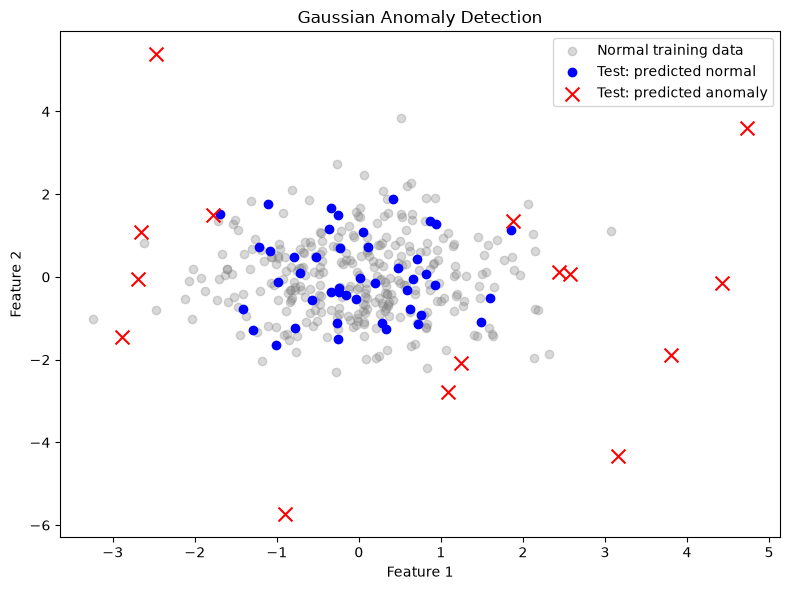

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_normal[:, 0], X_normal[:, 1], alpha=0.3, color='gray', label='Normal training data')
ax.scatter(X_test_ad[predictions == 0, 0], X_test_ad[predictions == 0, 1],
           color='blue', label='Test: predicted normal')
ax.scatter(X_test_ad[predictions == 1, 0], X_test_ad[predictions == 1, 1],
           color='red', marker='x', s=100, label='Test: predicted anomaly')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Gaussian Anomaly Detection')
ax.legend()
plt.tight_layout()
plt.show()

**Code:** Using scikit-learn's IsolationForest as a practical alternative — no distribution assumptions, handles multi-dimensional structure automatically.

In [41]:
from sklearn.ensemble import IsolationForest

# IsolationForest builds an ensemble of random trees; points that get isolated
# in fewer splits (closer to the tree root) are scored as more anomalous
iso_forest = IsolationForest(
    n_estimators=100,     # number of trees in the ensemble — more trees = more stable anomaly scores
    contamination=0.15,   # expected proportion of anomalies in the data — informs the decision threshold (10/60 ≈ 0.17 here)
    random_state=42
)

# fit_predict returns -1 for anomalies, 1 for normal points (sklearn's convention, not 0/1)
iso_predictions = iso_forest.fit_predict(X_test_ad)
iso_predictions_binary = (iso_predictions == -1).astype(int)  # convert to 0/1 to match our earlier convention

print(f"Isolation Forest flagged {iso_predictions_binary.sum()} anomalies")

from sklearn.metrics import classification_report
print("\nClassification report (Isolation Forest vs ground truth):")
print(classification_report(y_test_ad, iso_predictions_binary, target_names=['Normal', 'Anomaly']))

Isolation Forest flagged 9 anomalies

Classification report (Isolation Forest vs ground truth):
              precision    recall  f1-score   support

      Normal       0.94      0.96      0.95        50
     Anomaly       0.78      0.70      0.74        10

    accuracy                           0.92        60
   macro avg       0.86      0.83      0.84        60
weighted avg       0.91      0.92      0.91        60



### What is Markov Chains and why do we need them in ML?

**Markov Chain** — a mathematical model describing a system that moves between a set of **states**, where the probability of moving to the next state depends **only on the current state**, not on the sequence of states that came before it. This is called the **Markov property** ("memorylessness").

P(next state | current state, all past states) = P(next state | current state)

**Components of a Markov Chain:**
- **States** — the possible situations the system can be in (e.g. "machine running normally," "machine in warning state," "machine failed")
- **Transition probabilities** — the probability of moving from one state to another in a single step, usually shown as a **transition matrix**

**Why we need this in ML — specifically Reinforcement Learning:**

Markov Chains are the foundation of the **Markov Decision Process (MDP)**, which is the formal framework underlying Reinforcement Learning (Ng's Course 3, Week 3). An MDP extends a basic Markov Chain by adding:
- **Actions** — the agent doesn't just passively transition between states; it chooses actions that influence which state comes next
- **Rewards** — each state (or state-action pair) has an associated reward, which the agent tries to maximize over time
- **Policy** — the strategy mapping states to actions, which RL algorithms are trying to learn/optimize

**Why the Markov property matters for RL:** it means the agent only needs to know the **current state** to decide the best action — it doesn't need to remember the entire history of how it got there. This massively simplifies the problem; without this assumption, you'd need to track and reason over the entire sequence of past states, which becomes computationally intractable.

**Relevance to your role:** Reinforcement Learning is explicitly **out of day-1 scope** per your own notes (classical ML/stats focused role, not RL). This is worth understanding conceptually since it's in the Specialization, but you're very unlikely to apply Markov Chains/MDPs directly in your SECOM-style classification work. Where Markov Chains *do* occasionally show up in manufacturing/semiconductor contexts is **equipment state modeling** (predicting transitions between machine states like idle → running → maintenance → failure) — a tangential connection worth knowing exists, but not something to prioritize studying deeply right now.

**Pipeline stage:** Markov Chains/MDPs define the **problem formulation** for RL — they're the mathematical structure the entire RL algorithm (value functions, policies, Q-learning, etc.) is built on top of, not a preprocessing or evaluation step like most of your other questions.

**Code:** Building a simple Markov Chain with a transition matrix representing machine states (Running, Warning, Failed), then simulating how the system evolves over time.

In [42]:
import numpy as np

# Define states — a simplified illustration of equipment condition monitoring
states = ['Running', 'Warning', 'Failed']

# Transition matrix: rows = current state, columns = next state
# Each row must sum to 1.0 (it's a probability distribution over "what happens next")
transition_matrix = np.array([
    [0.90, 0.08, 0.02],  # from Running: 90% stay Running, 8% go to Warning, 2% go to Failed
    [0.30, 0.60, 0.10],  # from Warning: 30% recover to Running, 60% stay Warning, 10% go to Failed
    [0.00, 0.00, 1.00],  # from Failed: stays Failed (an "absorbing state" — no way back without intervention)
])

print("Transition matrix (rows sum to 1.0):")
for i, state in enumerate(states):
    print(f"{state}: {transition_matrix[i]} (sum={transition_matrix[i].sum():.2f})")

Transition matrix (rows sum to 1.0):
Running: [0.9  0.08 0.02] (sum=1.00)
Failed: [0. 0. 1.] (sum=1.00)


**Code:** Simulating the Markov Chain forward over many time steps, starting from "Running," to see how the system's state evolves — this uses only the CURRENT state to decide the next state, illustrating the Markov property directly.

In [43]:
np.random.seed(42)

def simulate_markov_chain(transition_matrix, states, start_state_idx, n_steps):
    # Simulates the chain by, at each step, sampling the next state using ONLY
    # the current state's row of transition probabilities — no memory of earlier states used
    current_state_idx = start_state_idx
    history = [states[current_state_idx]]

    for _ in range(n_steps):
        # np.random.choice samples the next state index according to the
        # current state's transition probabilities (a weighted random choice)
        next_state_idx = np.random.choice(
            len(states),                          # choose from state indices 0, 1, 2
            p=transition_matrix[current_state_idx]  # probability weights = current state's row
        )
        history.append(states[next_state_idx])
        current_state_idx = next_state_idx  # move forward — only this matters for the next step

    return history

simulation = simulate_markov_chain(transition_matrix, states, start_state_idx=0, n_steps=30)
print("Simulated state sequence over 30 steps:")
print(" -> ".join(simulation))

Simulated state sequence over 30 steps:
Running -> Running -> Warning -> Warning -> Warning -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Warning -> Warning -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running -> Running


**Code:** Visualizing the simulated state sequence over time as a step plot, to see how the machine drifts between states before eventually reaching the absorbing "Failed" state.

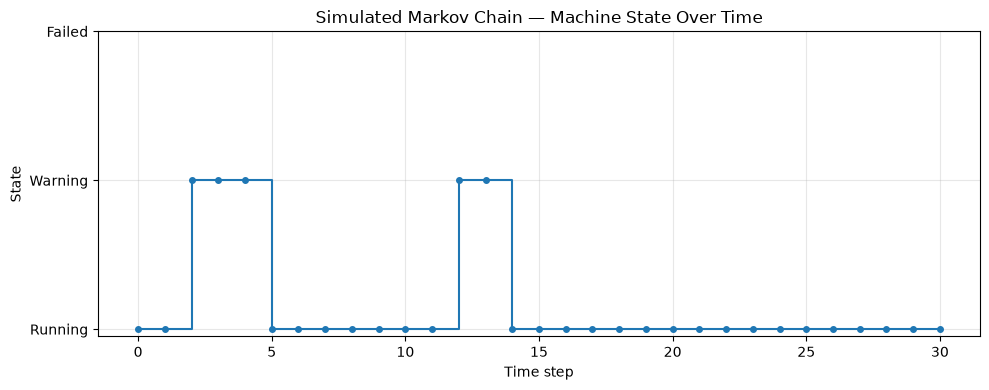

In [44]:
import matplotlib.pyplot as plt

# Map state names to numeric positions for plotting on the y-axis
state_to_num = {state: i for i, state in enumerate(states)}
numeric_sequence = [state_to_num[s] for s in simulation]

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(range(len(numeric_sequence)), numeric_sequence, where='post', marker='o', markersize=4)
ax.set_yticks(range(len(states)))
ax.set_yticklabels(states)
ax.set_xlabel('Time step')
ax.set_ylabel('State')
ax.set_title('Simulated Markov Chain — Machine State Over Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistics / Math for ML

### Why do we need to know if a dataset is normally distributed? What kind of ML uses it?

**Normal distribution (Gaussian)** — a symmetric, bell-shaped probability distribution defined by two parameters: **mean** (center) and **standard deviation** (spread). Many natural processes approximate this shape.

**Why it matters for ML — several distinct reasons:**

**1. Some algorithms explicitly assume normality:**
- **Linear/Logistic Regression** — doesn't require the *features* to be normal, but assumes the **residuals** (prediction errors) are normally distributed for statistical inference (confidence intervals, p-values on coefficients) to be valid. The predictions themselves can still be reasonable even if this is violated, but formal inference becomes unreliable.
- **Gaussian anomaly detection** — directly assumes each feature follows a normal distribution; if it doesn't, the probability estimates used to flag anomalies will be wrong
- **Linear Discriminant Analysis (LDA)** — assumes features are normally distributed within each class
- **Naive Bayes (Gaussian variant)** — assumes features follow a normal distribution given the class

**2. Statistical tests assume it:** many hypothesis tests (t-test, ANOVA, Pearson correlation significance) assume normality of the underlying data or residuals — violating this can make p-values and confidence intervals unreliable, especially with small sample sizes.

**3. It affects preprocessing choices:**
- If a feature is heavily **skewed** (not normal), applying a log/Box-Cox transformation to make it more normal-shaped can improve model performance for algorithms sensitive to this
- Outlier detection methods (like z-scores, "more than 3 standard deviations from the mean") assume normality — they'll misidentify outliers if the data is skewed

**What DOESN'T require normality:** tree-based models (Random Forest, XGBoost, Decision Trees) make **no distributional assumptions at all** — they split based on feature values/order, not on any underlying distribution shape. This is actually one reason tree-based models are often preferred for messy real-world sensor data (like SECOM) that doesn't naturally follow clean distributions.

**How to check for normality:**
- **Visual:** histogram, or a **Q-Q plot** (compares your data's quantiles against a theoretical normal distribution's quantiles — points falling on a straight diagonal line indicate normality)
- **Statistical tests:** Shapiro-Wilk test, D'Agostino's K² test — formal hypothesis tests for normality

**Relevance to SECOM:** with 591 sensor features, you'll likely find a mix — some sensors will be roughly normal, others heavily skewed or multi-modal. Checking this during EDA informs whether you need transformations, and whether Gaussian-based methods are appropriate for specific features.

**Pipeline stage:** this is an **EDA / preprocessing decision** step — checked early, before choosing models or transformations, typically right after initial data loading and before scaling/feature engineering.

**Code:** Checking normality visually (histogram + Q-Q plot) and statistically (Shapiro-Wilk test) for a normal vs. a skewed feature, side by side.

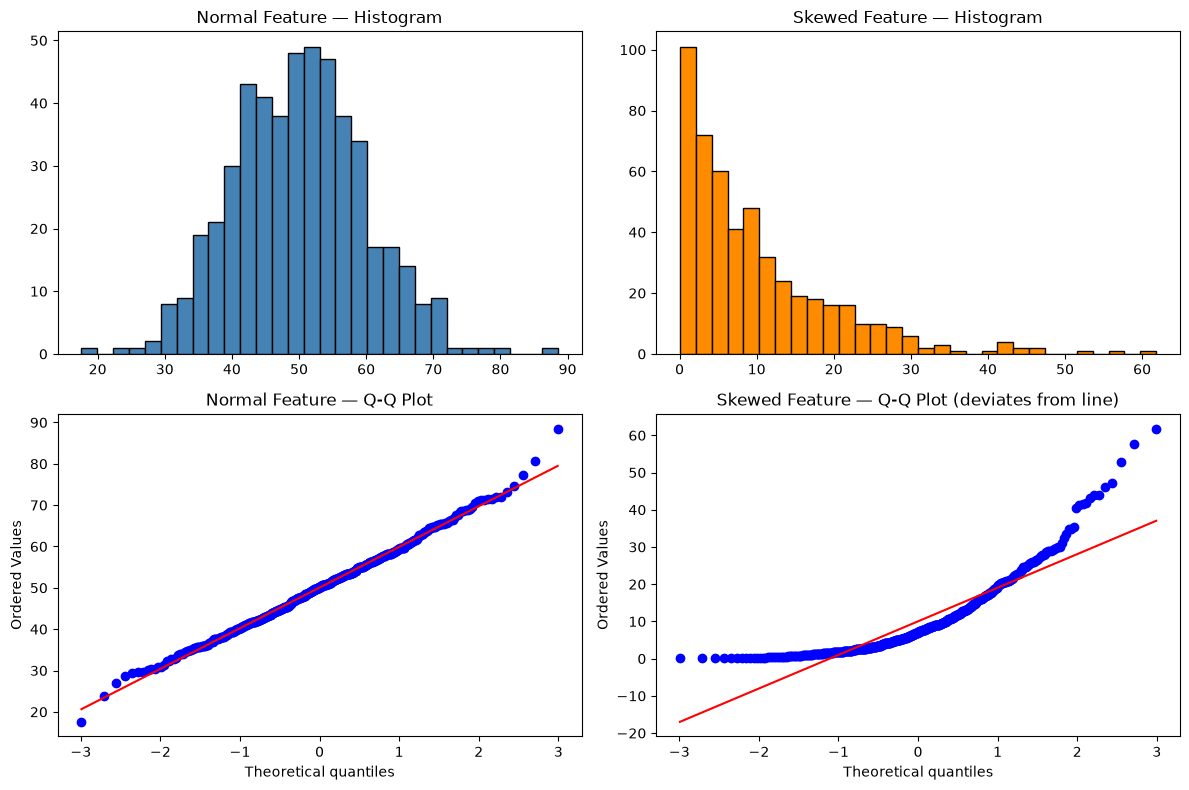

In [45]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

# Two example features: one genuinely normal, one heavily right-skewed
feature_normal = np.random.normal(loc=50, scale=10, size=500)
feature_skewed = np.random.exponential(scale=10, size=500)  # exponential distribution — classic right-skew shape

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(feature_normal, bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Normal Feature — Histogram')

axes[0, 1].hist(feature_skewed, bins=30, color='darkorange', edgecolor='black')
axes[0, 1].set_title('Skewed Feature — Histogram')

# Q-Q plots — compares sample quantiles against theoretical normal quantiles.
# Points on the diagonal red line = data matches a normal distribution.
stats.probplot(feature_normal, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Normal Feature — Q-Q Plot')

stats.probplot(feature_skewed, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Skewed Feature — Q-Q Plot (deviates from line)')

plt.tight_layout()
plt.show()

**Code:** Running the Shapiro-Wilk test formally on both features — a statistical hypothesis test for normality, complementing the visual check above.

In [46]:
# Shapiro-Wilk test: null hypothesis is "the data IS normally distributed"
# A small p-value (typically < 0.05) means we REJECT that null hypothesis —
# i.e. we have evidence the data is NOT normal
stat_normal, p_normal = stats.shapiro(feature_normal)
stat_skewed, p_skewed = stats.shapiro(feature_skewed)

print(f"Normal feature   — Shapiro-Wilk p-value: {p_normal:.4f}  "
      f"({'looks normal' if p_normal > 0.05 else 'NOT normal'})")
print(f"Skewed feature   — Shapiro-Wilk p-value: {p_skewed:.4f}  "
      f"({'looks normal' if p_skewed > 0.05 else 'NOT normal'})")

Normal feature   — Shapiro-Wilk p-value: 0.4013  (looks normal)
Skewed feature   — Shapiro-Wilk p-value: 0.0000  (NOT normal)


**Code:** Applying a log transformation to the skewed feature to see if it becomes more normally distributed — a common preprocessing fix when normality matters for your chosen model or statistical test.

Log-transformed skewed feature — Shapiro-Wilk p-value: 0.0001  (still NOT normal)


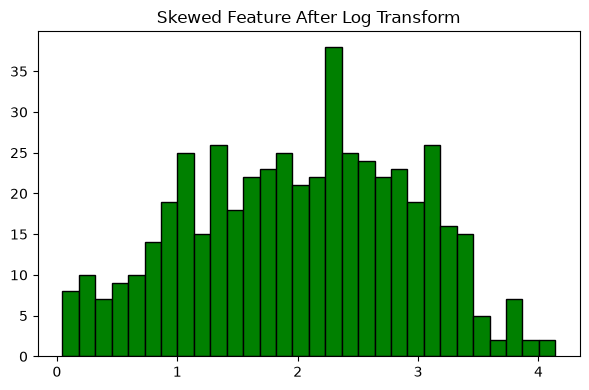

In [47]:
# log1p = log(1 + x), used instead of plain log() to safely handle values near 0
feature_skewed_log = np.log1p(feature_skewed)

stat_log, p_log = stats.shapiro(feature_skewed_log)
print(f"Log-transformed skewed feature — Shapiro-Wilk p-value: {p_log:.4f}  "
      f"({'looks normal' if p_log > 0.05 else 'still NOT normal'})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(feature_skewed_log, bins=30, color='green', edgecolor='black')
ax.set_title('Skewed Feature After Log Transform')
plt.tight_layout()
plt.show()

### D'Agostino's K² test

**D'Agostino's K² test** — an alternative formal test for normality, complementary to Shapiro-Wilk. Instead of directly comparing your data's shape to a normal distribution, it tests normality by combining two specific measures of distribution shape:

- **Skewness** — how asymmetric the distribution is (a perfect normal distribution has skewness = 0)
- **Kurtosis** — how heavy/light the "tails" of the distribution are compared to normal (a perfect normal distribution has kurtosis = 3, or "excess kurtosis" = 0)

The test combines these two into a single statistic and checks whether they're jointly consistent with a normal distribution.

**When to prefer it over Shapiro-Wilk:** Shapiro-Wilk tends to be more powerful (better at detecting non-normality) for **small sample sizes**. D'Agostino's K² is often preferred for **larger samples** and gives you interpretable skewness/kurtosis values along the way, which are useful diagnostics on their own (e.g. "this feature is right-skewed" tells you *how* it's non-normal, not just *that* it is).

**Practical takeaway:** you don't need both every time — pick one as your standard check. Shapiro-Wilk is more common as a default in practice.

**Pipeline stage:** same as Shapiro-Wilk — an **EDA / preprocessing decision** step.

**Code:** Running D'Agostino's K² test on the same normal and skewed features from before, and inspecting the skewness/kurtosis values it's based on.

In [48]:
from scipy import stats

# normaltest() implements D'Agostino and Pearson's test — null hypothesis is
# "the data IS normally distributed," same interpretation convention as Shapiro-Wilk
stat_normal_dag, p_normal_dag = stats.normaltest(feature_normal)
stat_skewed_dag, p_skewed_dag = stats.normaltest(feature_skewed)

print(f"Normal feature — D'Agostino K² p-value: {p_normal_dag:.4f}  "
      f"({'looks normal' if p_normal_dag > 0.05 else 'NOT normal'})")
print(f"Skewed feature — D'Agostino K² p-value: {p_skewed_dag:.4f}  "
      f"({'looks normal' if p_skewed_dag > 0.05 else 'NOT normal'})")

# The underlying skewness and kurtosis values the test is based on
print(f"\nSkewness — normal: {stats.skew(feature_normal):.3f}, skewed: {stats.skew(feature_skewed):.3f}")
print(f"Kurtosis — normal: {stats.kurtosis(feature_normal):.3f}, skewed: {stats.kurtosis(feature_skewed):.3f}")
print("(A perfectly normal distribution has skewness ≈ 0 and excess kurtosis ≈ 0)")

Normal feature — D'Agostino K² p-value: 0.1210  (looks normal)
Skewed feature — D'Agostino K² p-value: 0.0000  (NOT normal)

Skewness — normal: 0.180, skewed: 1.767
Kurtosis — normal: 0.256, skewed: 3.980
(A perfectly normal distribution has skewness ≈ 0 and excess kurtosis ≈ 0)


### What is and why do we need hypothesis testing in ML?

**Hypothesis testing** is a formal framework for deciding whether an observed pattern in your data is likely a **real effect** or just **due to random chance**.

**Simple example to build intuition:** Imagine a coffee shop wants to know: "Does putting a small tip jar with a smiley face on it get people to tip more than a plain jar?" They try the smiley jar for a week, the plain jar for another week, and see: smiley jar averaged $1.20/customer, plain jar averaged $1.05/customer. Is the smiley face actually working, or did that difference just happen by chance — maybe a few generous customers happened to come in that week?

**Why this is even a question:** even if the smiley face does absolutely nothing, tips measured over two different weeks will basically never be *exactly* equal — different customers, different moods, different days. There's always some random wiggle. So seeing a $0.15 difference doesn't automatically mean the smiley face worked — it might just be normal week-to-week randomness.

**The actual test, in plain steps:**

1. **Start by assuming it does nothing.** ("The smiley face has no real effect — any difference in tips is just random variation between weeks.") This is the **null hypothesis (H0)** — your default, boring assumption.

2. **Measure what you actually observed.** A $0.15 difference in average tips.

3. **Ask: "If the smiley face really did nothing, how often would two random weeks differ by $0.15 or more, just by chance?"** This is the **p-value**. Maybe the answer is "this size of difference happens by pure chance about 30% of the time" — pretty common, not convincing evidence of anything.

4. **Decide if that's rare enough to matter.** If instead the answer were "a difference this big would only happen by chance 2% of the time," that starts to feel like more than just luck. The common cutoff (**significance level, alpha**) is 5%: if the result would happen by chance less than 5% of the time, call it "statistically significant."

**The decision rule:**
- **p-value < alpha (usually 0.05)** → reject the null hypothesis → "this looks like a real effect, not just chance"
- **p-value >= alpha** → fail to reject the null hypothesis → "not enough evidence to rule out random chance"

**Two nuances worth internalizing early:**
1. **"Fail to reject" is not "accept."** A p-value above 0.05 doesn't prove the effect doesn't exist — it just means the evidence wasn't strong enough to confidently rule out chance. Absence of proof isn't proof of absence.
2. **The 5% threshold is a convention, not a law of nature.** A stricter threshold (1%) is used when being wrong is costly; a looser one (10%) for early exploratory work. 5% is the near-universal default unless there's a specific reason to change it.

**The key intuition:** you're never *proving* an effect is real. You're asking: "Is the evidence strong enough that I'm no longer comfortable blaming it on random luck?" A p-value of 2% doesn't mean "98% chance the effect is real" — it means "if the effect truly didn't exist, a result this extreme would only show up 2% of the time by chance alone."

**Analogy:** it's a courtroom. You start assuming "innocent" (null hypothesis = no real effect). You only convict (reject the null) if the evidence is strong enough to be very unlikely under an assumption of innocence. You never reach 100% certainty either way — just "the evidence crossed my threshold."

**Why this matters in ML specifically:**
- **Feature selection** — testing whether a feature has a statistically significant relationship with the target before including it in a model
- **A/B testing** — comparing two model versions in production (does the new model's defect-catch rate significantly beat the old one, or is the difference just noise?)
- **Comparing model performance** — testing whether Model A's accuracy is significantly better than Model B's, not just numerically higher
- **Validating assumptions** — testing whether data is normal, whether groups differ, whether variables are related — this entire family of tools is built on the hypothesis testing framework

**Type I and Type II errors:**
- **Type I error (false positive)** — rejecting H0 when it's actually true
- **Type II error (false negative)** — failing to reject H0 when it's actually false
- This directly parallels precision/recall tradeoffs in classification — same underlying tension between two error types, different vocabulary

**Pipeline stage:** used throughout — during **EDA** (checking feature relationships, normality), during **model comparison/evaluation** (is Model A meaningfully better?), and in **production monitoring** (A/B tests, drift detection).

**Code:** Simulating the coffee shop tip jar scenario — running a hypothesis test on two groups of simulated tip data, and visualizing what the p-value actually represents.

In [49]:
from scipy import stats
import numpy as np

np.random.seed(42)

# Simulate tip amounts for two groups: plain jar week vs smiley face jar week
# Here we build in a REAL difference (means $1.05 vs $1.20), to illustrate detecting a true effect
tips_plain_jar = np.random.normal(loc=1.05, scale=0.40, size=150)   # 150 customers, plain jar week
tips_smiley_jar = np.random.normal(loc=1.20, scale=0.40, size=150)  # 150 customers, smiley jar week

# Independent two-sample t-test: tests H0 = "the two groups have the same average tip"
t_stat, p_value = stats.ttest_ind(tips_plain_jar, tips_smiley_jar)

alpha = 0.05  # significance threshold, decided BEFORE looking at results

print(f"Plain jar average tip:  ${tips_plain_jar.mean():.2f}")
print(f"Smiley jar average tip: ${tips_smiley_jar.mean():.2f}")
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < alpha:
    print(f"\np-value < {alpha} → reject H0: the smiley face likely has a real effect on tipping")
else:
    print(f"\np-value >= {alpha} → fail to reject H0: not enough evidence the smiley face changes tipping")

Plain jar average tip:  $1.02
Smiley jar average tip: $1.23

t-statistic: -4.657
p-value: 0.0000

p-value < 0.05 → reject H0: the smiley face likely has a real effect on tipping


**Code:** Visualizing what the p-value represents — the null distribution (what t-statistics would look like if the smiley face truly had no effect), with the observed t-statistic marked to show how extreme it is relative to that null.

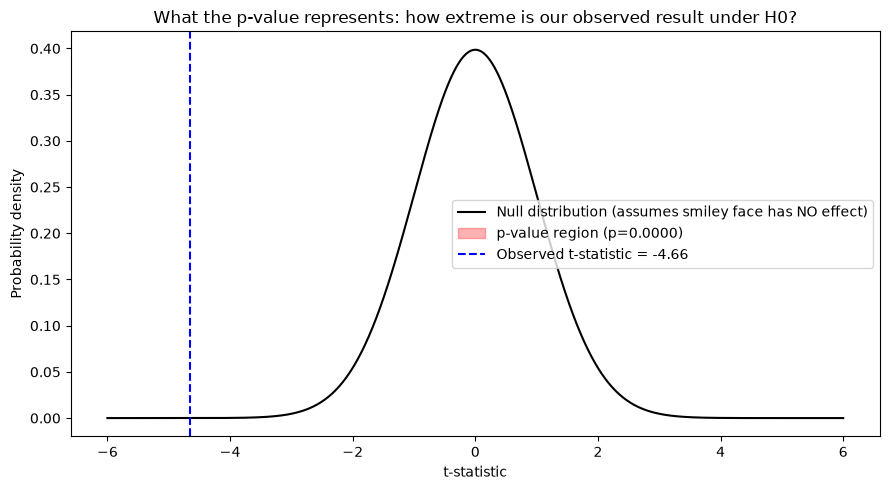

In [50]:
import matplotlib.pyplot as plt

# Under H0, the t-statistic follows a t-distribution with (n1 + n2 - 2) degrees of freedom
df = len(tips_plain_jar) + len(tips_smiley_jar) - 2
x = np.linspace(-6, 6, 1000)
null_distribution = stats.t.pdf(x, df)  # the theoretical distribution of t-values IF H0 were true

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, null_distribution, label='Null distribution (assumes smiley face has NO effect)', color='black')

# Shade the region(s) as extreme or more extreme than the observed t-statistic —
# this shaded area IS the p-value
ax.fill_between(x, null_distribution, where=(np.abs(x) >= abs(t_stat)),
                 color='red', alpha=0.3, label=f'p-value region (p={p_value:.4f})')
ax.axvline(t_stat, color='blue', linestyle='--', label=f'Observed t-statistic = {t_stat:.2f}')

ax.set_xlabel('t-statistic')
ax.set_ylabel('Probability density')
ax.set_title('What the p-value represents: how extreme is our observed result under H0?')
ax.legend()
plt.tight_layout()
plt.show()

### What is and why do we need t-test in ML?

**t-test** — a specific statistical test that compares the **means** of one or two groups, to determine if an observed difference is likely real or just random chance. It's one concrete implementation of the hypothesis testing framework — the t-test *is* the tool; hypothesis testing is the *general framework* it operates within.

**Why "t"?** The test statistic follows a **t-distribution** (similar to a normal distribution, but with heavier tails — accounts for extra uncertainty when working with smaller sample sizes, where you're estimating both the mean and the spread from limited data).

**Three main variants:**

**1. One-sample t-test** — compares a single group's mean against a known/expected value (e.g. "is our sensor's average reading significantly different from the spec value of 50.0?")

**2. Independent two-sample t-test** — compares the means of two *separate/independent* groups (e.g. pass-chips sensor reading vs fail-chips sensor reading). This is the most commonly used variant in exploratory feature analysis.

**3. Paired t-test** — compares two measurements taken on the **same subjects** at two different times/conditions (e.g. the same machine's output before vs. after a calibration adjustment). This accounts for the fact that paired data isn't independent — each pair shares a common source of variation that the test can factor out, making it more sensitive than treating them as two separate independent groups.

**Key assumptions (worth knowing, since violating them undermines the test's validity):**
- Data in each group is **approximately normally distributed** — though t-tests are fairly robust to mild violations, especially with larger sample sizes
- **Independent samples** (except for the paired variant, which specifically handles dependence)
- Similar variance between groups, for the standard two-sample test (there's a variant — Welch's t-test — that doesn't require this assumption, and is actually the safer default)

**When it's NOT appropriate:** if your data is heavily non-normal and your sample size is small, or if you're comparing **more than two groups**, a t-test isn't the right tool — use ANOVA for 3+ groups, or a non-parametric alternative (Mann-Whitney U) if normality is badly violated.

**Relevance to your role:** directly useful for SECOM-style EDA — testing whether a specific sensor's readings genuinely differ between pass/fail lots, before deciding it's a meaningful feature, rather than eyeballing a difference in means and assuming it's real.

**Pipeline stage:** an **EDA / feature evaluation** step, typically used early — before model training — to help decide which features are worth including, or to validate observed differences during exploratory analysis.

**Code:** Running all three t-test variants — one-sample, independent two-sample, and paired — on simple synthetic examples that make the difference between them concrete.

In [51]:
from scipy import stats
import numpy as np

np.random.seed(42)

# --- 1. One-sample t-test ---
# Question: is this sensor's average reading significantly different from the spec value of 50.0?
sensor_readings = np.random.normal(loc=51.2, scale=3, size=40)  # 40 readings, true mean slightly off-spec
spec_value = 50.0

t_stat_1samp, p_value_1samp = stats.ttest_1samp(sensor_readings, popmean=spec_value)
print("--- One-sample t-test ---")
print(f"Sample mean: {sensor_readings.mean():.2f}, testing against spec value: {spec_value}")
print(f"t-statistic: {t_stat_1samp:.3f}, p-value: {p_value_1samp:.4f}")

# --- 2. Independent two-sample t-test (Welch's, the safer default — doesn't assume equal variance) ---
# Question: does this sensor genuinely differ between pass and fail chips?
sensor_pass = np.random.normal(loc=50.0, scale=3, size=60)
sensor_fail = np.random.normal(loc=52.5, scale=3, size=60)

t_stat_2samp, p_value_2samp = stats.ttest_ind(
    sensor_pass, sensor_fail,
    equal_var=False   # Welch's t-test — doesn't assume the two groups have equal variance, generally safer
)
print("\n--- Independent two-sample t-test (Welch's) ---")
print(f"Pass mean: {sensor_pass.mean():.2f}, Fail mean: {sensor_fail.mean():.2f}")
print(f"t-statistic: {t_stat_2samp:.3f}, p-value: {p_value_2samp:.4f}")

# --- 3. Paired t-test ---
# Question: did calibrating the machine significantly change this sensor's readings on the SAME units?
before_calibration = np.random.normal(loc=50.0, scale=2, size=30)
# after_calibration is deliberately built AS a shifted version of the same units, to show pairing
after_calibration = before_calibration + np.random.normal(loc=1.5, scale=0.5, size=30)

t_stat_paired, p_value_paired = stats.ttest_rel(before_calibration, after_calibration)
print("\n--- Paired t-test ---")
print(f"Mean before: {before_calibration.mean():.2f}, Mean after: {after_calibration.mean():.2f}")
print(f"t-statistic: {t_stat_paired:.3f}, p-value: {p_value_paired:.4f}")

--- One-sample t-test ---
Sample mean: 50.54, testing against spec value: 50.0
t-statistic: 1.204, p-value: 0.2359

--- Independent two-sample t-test (Welch's) ---
Pass mean: 49.92, Fail mean: 52.48
t-statistic: -5.008, p-value: 0.0000

--- Paired t-test ---
Mean before: 50.30, Mean after: 51.91
t-statistic: -17.627, p-value: 0.0000


**Code:** Visualizing the three scenarios side by side, showing what each t-test variant is actually comparing.

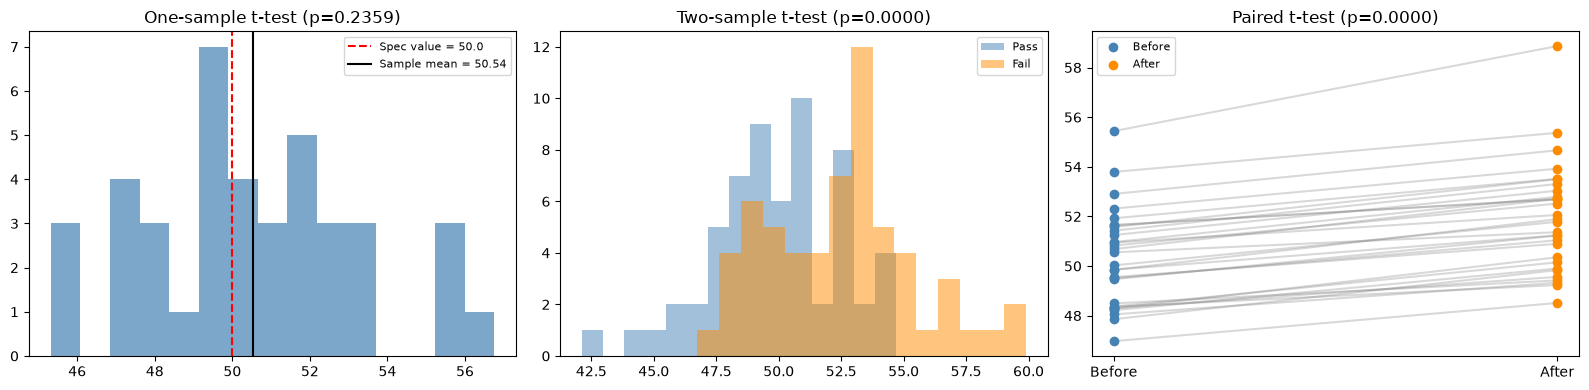

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# One-sample: single group's distribution vs a fixed reference line
axes[0].hist(sensor_readings, bins=15, color='steelblue', alpha=0.7)
axes[0].axvline(spec_value, color='red', linestyle='--', label=f'Spec value = {spec_value}')
axes[0].axvline(sensor_readings.mean(), color='black', linestyle='-', label=f'Sample mean = {sensor_readings.mean():.2f}')
axes[0].set_title(f'One-sample t-test (p={p_value_1samp:.4f})')
axes[0].legend(fontsize=8)

# Independent two-sample: two separate groups' distributions
axes[1].hist(sensor_pass, bins=15, alpha=0.5, label='Pass', color='steelblue')
axes[1].hist(sensor_fail, bins=15, alpha=0.5, label='Fail', color='darkorange')
axes[1].set_title(f'Two-sample t-test (p={p_value_2samp:.4f})')
axes[1].legend(fontsize=8)

# Paired: connecting lines showing each unit's before/after value
for i in range(len(before_calibration)):
    axes[2].plot([0, 1], [before_calibration[i], after_calibration[i]], color='gray', alpha=0.3)
axes[2].scatter(np.zeros(len(before_calibration)), before_calibration, color='steelblue', label='Before', zorder=5)
axes[2].scatter(np.ones(len(after_calibration)), after_calibration, color='darkorange', label='After', zorder=5)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Before', 'After'])
axes[2].set_title(f'Paired t-test (p={p_value_paired:.4f})')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Code:** Running a one-way ANOVA comparing a sensor's readings across 4 different machine tools/chambers, to test whether any tool differs significantly from the others.

In [53]:
from scipy import stats
import numpy as np

np.random.seed(42)

# Simulate a sensor reading across 4 different machine chambers
# Chamber 3 is deliberately built with a different mean, to illustrate detecting a real group difference
chamber_1 = np.random.normal(loc=50.0, scale=3, size=40)
chamber_2 = np.random.normal(loc=50.3, scale=3, size=40)
chamber_3 = np.random.normal(loc=53.5, scale=3, size=40)  # this one is meaningfully different
chamber_4 = np.random.normal(loc=49.8, scale=3, size=40)

# One-way ANOVA: tests H0 = "all group means are equal"
f_stat, p_value = stats.f_oneway(chamber_1, chamber_2, chamber_3, chamber_4)

alpha = 0.05
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.6f}")

if p_value < alpha:
    print(f"\np-value < {alpha} → reject H0: at least one chamber's mean differs significantly")
else:
    print(f"\np-value >= {alpha} → fail to reject H0: no significant difference detected between chambers")

F-statistic: 18.539
p-value: 0.000000

p-value < 0.05 → reject H0: at least one chamber's mean differs significantly


**Code:** Since ANOVA only tells us SOMETHING differs, running a post-hoc Tukey's HSD test to identify WHICH specific chamber pairs differ significantly.

In [54]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Reshape data into the long format Tukey's test expects: one column of values, one column of group labels
values = np.concatenate([chamber_1, chamber_2, chamber_3, chamber_4])
groups = (['Chamber 1'] * len(chamber_1) + ['Chamber 2'] * len(chamber_2) +
          ['Chamber 3'] * len(chamber_3) + ['Chamber 4'] * len(chamber_4))

tukey_result = pairwise_tukeyhsd(
    endog=values,   # the measured values (sensor readings)
    groups=groups,   # the group label for each value
    alpha=0.05        # significance level for each pairwise comparison
)

print(tukey_result)  # shows every pairwise comparison, with adjusted p-values and reject/fail-to-reject decisions

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Chamber 1 Chamber 2   0.8688 0.5162 -0.7708  2.5084  False
Chamber 1 Chamber 3   4.1864    0.0  2.5468   5.826   True
Chamber 1 Chamber 4   0.3572 0.9421 -1.2824  1.9968  False
Chamber 2 Chamber 3   3.3176    0.0   1.678  4.9573   True
Chamber 2 Chamber 4  -0.5116 0.8495 -2.1512   1.128  False
Chamber 3 Chamber 4  -3.8292    0.0 -5.4688 -2.1896   True
----------------------------------------------------------


**Code:** Visualizing all 4 chambers' distributions side by side with a boxplot — makes it visually clear which chamber stands out before even looking at the statistical results.

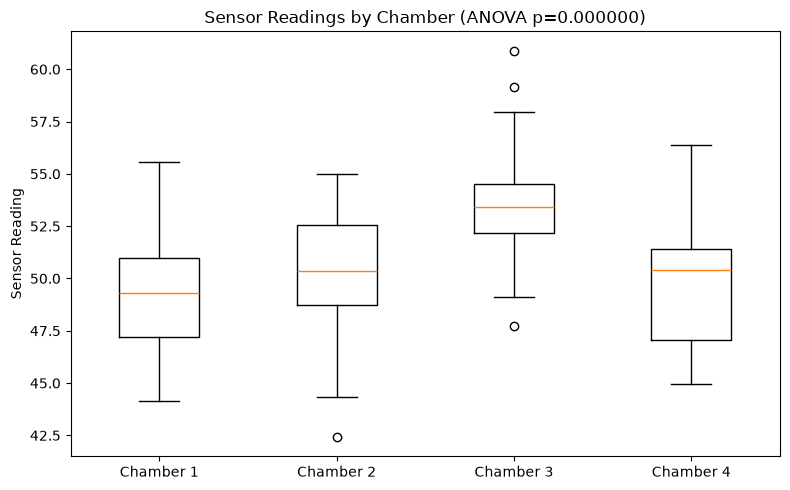

In [55]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([chamber_1, chamber_2, chamber_3, chamber_4],
           tick_labels=['Chamber 1', 'Chamber 2', 'Chamber 3', 'Chamber 4'])
ax.set_ylabel('Sensor Reading')
ax.set_title(f'Sensor Readings by Chamber (ANOVA p={p_value:.6f})')
plt.tight_layout()
plt.show()

### Pearson correlation

**Pearson correlation coefficient (r)** measures the strength and direction of the **linear** relationship between two continuous variables, on a scale from **-1 to +1**.

- **r = +1** — perfect positive linear relationship (as one variable increases, the other increases proportionally)
- **r = -1** — perfect negative linear relationship (as one increases, the other decreases proportionally)
- **r = 0** — no linear relationship
- Values in between indicate the strength — e.g. r = 0.7 is a fairly strong positive relationship, r = 0.1 is very weak

**How it's calculated, intuitively:** it measures how consistently two variables move together relative to their own means — for each data point, it checks whether both variables are above their mean together, or below their mean together (positive correlation), or opposite (negative correlation), and averages this consistency across all points, normalized by each variable's spread.

**Correlation coefficient vs. correlation significance — two different things:**
- **r** (the coefficient) tells you the **strength/direction** of the relationship
- The **p-value** associated with it tells you whether that correlation is **statistically significant** — i.e. unlikely to have arisen by chance, tying this back to the hypothesis testing framework. With a small sample, even a fairly large r might not be statistically significant; with a huge sample, even a tiny, practically meaningless r can come out "significant."

**Important limitation — the one thing to always remember:** Pearson correlation only captures **linear** relationships. Two variables can have a strong, obvious *non-linear* relationship (e.g. a U-shape) and still show r ≈ 0, because Pearson literally cannot detect anything except straight-line patterns. Always look at a scatter plot alongside the number — never trust r alone.

**Correlation is not causation:** a strong correlation between two sensors doesn't mean one causes the other — they might both be driven by a third factor (e.g. ambient temperature affecting two unrelated sensors simultaneously).

**Assumptions:** works best when both variables are roughly normally distributed and the relationship (if any) is genuinely linear — this is why it pairs naturally with the earlier normality-checking question.

**Relevance to your role:** this is one of the most-used EDA tools you'll reach for — computing a **correlation matrix** across SECOM's 591 features to spot redundant/highly correlated sensors (candidates for removal, or a signal that PCA would help), and to get an early read on which features might relate to the pass/fail outcome before formal modeling.

**Pipeline stage:** **EDA** — one of the first things typically done after loading and cleaning data, before modeling.

**Code:** Computing Pearson correlation between two features with a genuine linear relationship, and visualizing it with a scatter plot alongside the correlation value.

In [56]:
from scipy import stats
import numpy as np

np.random.seed(42)

# Two features with a real, moderately strong linear relationship, plus noise
feature_x = np.random.normal(loc=50, scale=10, size=200)
feature_y = 0.8 * feature_x + np.random.normal(loc=0, scale=5, size=200)  # y depends on x, plus noise

# pearsonr returns both the correlation coefficient (r) and its associated p-value
r, p_value = stats.pearsonr(feature_x, feature_y)

print(f"Pearson correlation (r): {r:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"Interpretation: {'statistically significant' if p_value < 0.05 else 'not significant'} "
      f"{'positive' if r > 0 else 'negative'} linear relationship")

Pearson correlation (r): 0.850
p-value: 0.000000
Interpretation: statistically significant positive linear relationship


**Code:** Demonstrating Pearson correlation's key limitation — a clear non-linear (U-shaped) relationship that Pearson fails to detect, showing why you should never trust the number without also looking at a scatter plot.

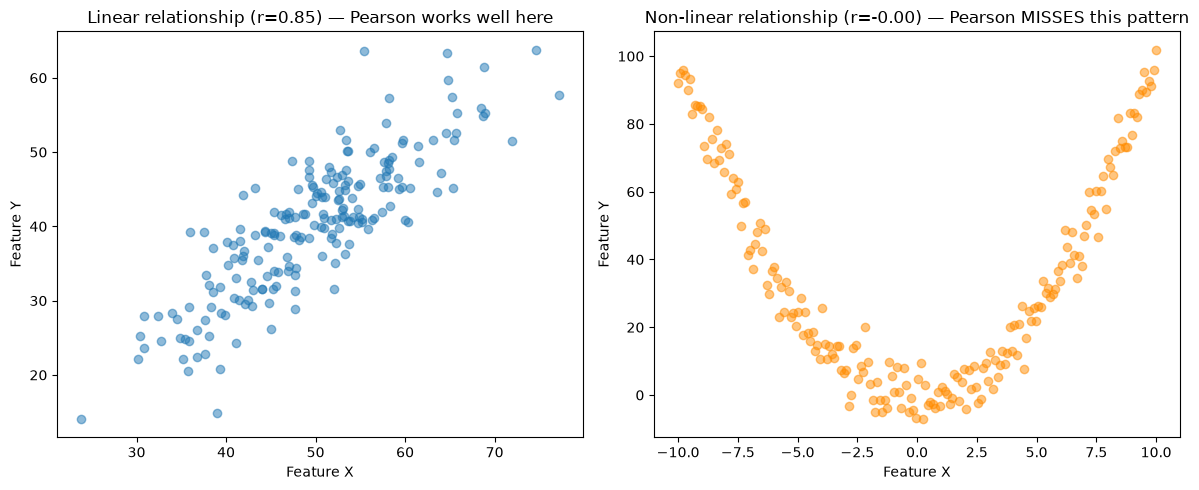

Non-linear example — Pearson r: -0.001 (misleadingly close to 0, despite an obvious strong pattern)


In [57]:
import matplotlib.pyplot as plt

# A clear, strong relationship — but non-linear (quadratic/U-shaped)
feature_x_nonlin = np.linspace(-10, 10, 200)
feature_y_nonlin = feature_x_nonlin ** 2 + np.random.normal(0, 5, 200)  # U-shape, plus noise

r_nonlin, p_nonlin = stats.pearsonr(feature_x_nonlin, feature_y_nonlin)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(feature_x, feature_y, alpha=0.5)
axes[0].set_title(f'Linear relationship (r={r:.2f}) — Pearson works well here')
axes[0].set_xlabel('Feature X')
axes[0].set_ylabel('Feature Y')

axes[1].scatter(feature_x_nonlin, feature_y_nonlin, alpha=0.5, color='darkorange')
axes[1].set_title(f'Non-linear relationship (r={r_nonlin:.2f}) — Pearson MISSES this pattern')
axes[1].set_xlabel('Feature X')
axes[1].set_ylabel('Feature Y')

plt.tight_layout()
plt.show()

print(f"Non-linear example — Pearson r: {r_nonlin:.3f} (misleadingly close to 0, despite an obvious strong pattern)")

**Code:** Building a correlation matrix/heatmap across multiple features at once — the standard way to scan for redundant or highly correlated features during EDA, directly applicable to a high-dimensional dataset like SECOM.

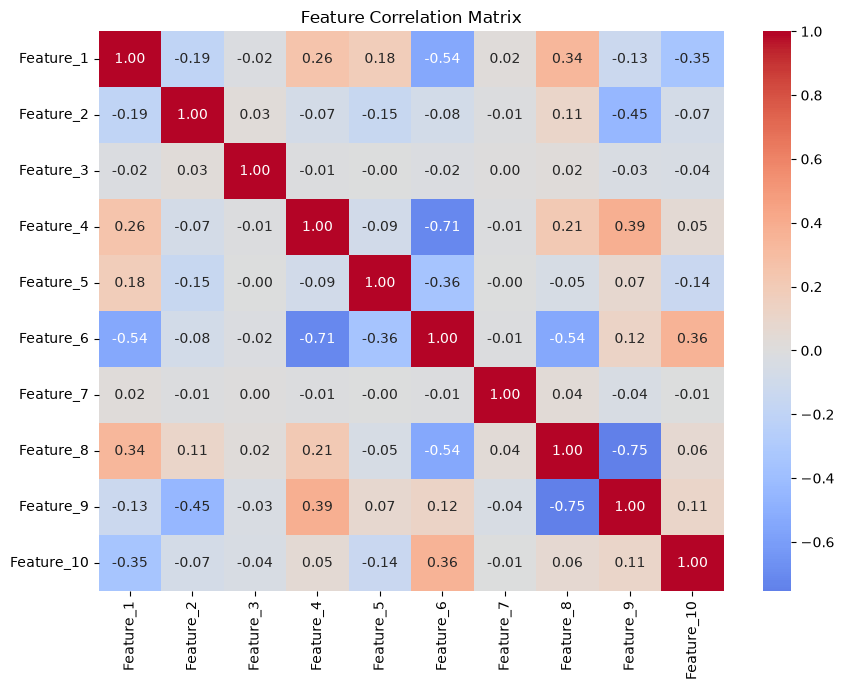

In [58]:
import pandas as pd
import seaborn as sns

# Reuse the shared X_train dataset, converting to a DataFrame for readable feature names
X_train_df = pd.DataFrame(X_train, columns=[f'Feature_{i+1}' for i in range(X_train.shape[1])])

# .corr() computes pairwise Pearson correlation between every pair of columns at once
corr_matrix = X_train_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,       # show the correlation value in each cell
    fmt='.2f',         # format numbers to 2 decimal places
    cmap='coolwarm',   # blue = negative correlation, red = positive
    center=0,           # center the color scale at 0 (no correlation)
    ax=ax
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Chi-square test

**Chi-square test (χ²)** tests whether two **categorical** variables are related/associated, or independent of each other. Unlike everything covered so far (which dealt with continuous numeric data), this is specifically for categorical data — counts of things in categories, not measured values.

**Example question it answers:** "Is defect type associated with which machine tool produced the part, or are defects randomly distributed across tools regardless of which tool it is?"

**How it works, intuitively:**
1. Build a **contingency table** — a cross-tabulation of counts for every combination of the two categorical variables (e.g. rows = machine tool, columns = defect type, cells = count of parts with that tool/defect combination)
2. Calculate what the counts in each cell **would look like if the two variables were completely independent** (the "expected" counts, based purely on the row/column totals)
3. Compare your **actual observed counts** to those **expected counts** — the bigger the gap, the more evidence the variables are actually related, not independent
4. This comparison produces the chi-square statistic, and from it, a p-value

**Null and alternative hypothesis:**
- **H0:** the two categorical variables are independent (no association)
- **H1:** the two categorical variables are associated

**When to use it vs. other tests:**
- **Chi-square** — both variables are categorical (e.g. machine tool x defect type)
- **t-test/ANOVA** — comparing a continuous variable's mean across categorical groups (e.g. sensor reading x machine tool)
- **Pearson correlation** — both variables are continuous

**Assumptions/requirements:**
- Expected cell counts should generally be at least 5 in most cells (chi-square becomes unreliable with very sparse contingency tables — small counts spread across many categories)
- Observations must be independent of each other

**Relevance to your role:** useful whenever you're relating two categorical fields in your data — e.g. "is a specific defect code associated with a specific shift/operator/tool?" — a common quality-engineering question in a fab context, complementary to the continuous-variable tests (t-test/ANOVA/correlation) you'll use far more often on SECOM's numeric sensor data.

**Pipeline stage:** **EDA** — used to explore relationships between categorical variables, typically before deciding which categorical features are worth encoding/including in a model.

**Code:** Building a contingency table of two categorical variables (machine tool x defect type) and running a chi-square test to check whether they're associated.

In [59]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

np.random.seed(42)

# Simulate categorical data: which tool produced each part, and what defect (if any) it had
# Deliberately building in a real association: Tool_C produces disproportionately more Type_B defects
n_samples = 300
tools = np.random.choice(['Tool_A', 'Tool_B', 'Tool_C'], size=n_samples, p=[0.4, 0.35, 0.25])

defect_types = []
for tool in tools:
    if tool == 'Tool_C':
        # Tool_C skews heavily toward Type_B defects — the real association we're testing for
        defect_types.append(np.random.choice(['Type_A', 'Type_B', 'None'], p=[0.1, 0.5, 0.4]))
    else:
        defect_types.append(np.random.choice(['Type_A', 'Type_B', 'None'], p=[0.2, 0.15, 0.65]))

df_categorical = pd.DataFrame({'Tool': tools, 'Defect': defect_types})

# Build the contingency table — cross-tab of counts for every Tool x Defect combination
contingency_table = pd.crosstab(df_categorical['Tool'], df_categorical['Defect'])
print("Contingency table (observed counts):")
print(contingency_table)

# chi2_contingency runs the test and also returns the "expected" counts under independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\np-value < 0.05 → reject H0: Tool and Defect type appear to be associated")
else:
    print("\np-value >= 0.05 → fail to reject H0: no significant association detected")

Contingency table (observed counts):
Defect  None  Type_A  Type_B
Tool                        
Tool_A    90      24      15
Tool_B    67      24       4
Tool_C    28      12      36

Chi-square statistic: 60.739
Degrees of freedom: 4
p-value: 0.000000

p-value < 0.05 → reject H0: Tool and Defect type appear to be associated


**Code:** Visualizing observed vs expected counts side by side — this makes concrete what the chi-square test is actually measuring: the gap between what we saw and what we'd expect if the variables were unrelated.

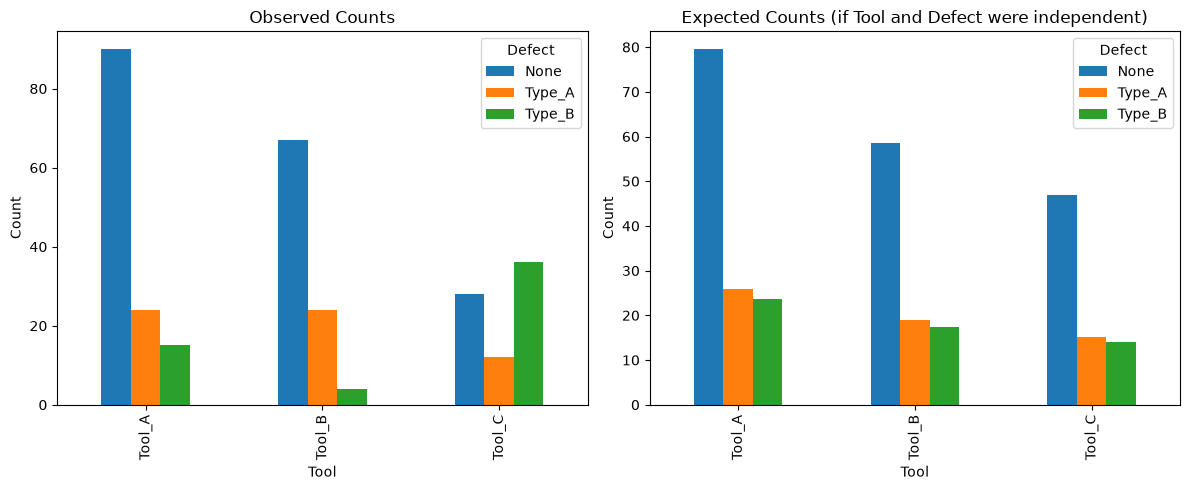

Notice how Tool_C's actual Type_B count is much higher than its expected count —
that gap is what drives the significant chi-square result.


In [60]:
import matplotlib.pyplot as plt

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

contingency_table.plot(kind='bar', ax=axes[0])
axes[0].set_title('Observed Counts')
axes[0].set_ylabel('Count')

expected_df.plot(kind='bar', ax=axes[1])
axes[1].set_title('Expected Counts (if Tool and Defect were independent)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Notice how Tool_C's actual Type_B count is much higher than its expected count —")
print("that gap is what drives the significant chi-square result.")

**Code:** Running a KS test comparing two samples from the SAME distribution (should show no significant difference) vs two samples from genuinely DIFFERENT distributions (should show a significant difference) — illustrating what the test detects.

### Kolmogorov-Smirnov (KS) test

**KS test** checks whether two samples come from the **same underlying distribution** — or whether a single sample matches a specific theoretical distribution (e.g. testing if data is normal, similar to Shapiro-Wilk but via a different method). Unlike the t-test/ANOVA (which only compare **means**), the KS test compares the entire **shape** of the distributions — mean, spread, skew, everything at once.

**How it works, intuitively:**
1. For both samples, build the **empirical cumulative distribution function (CDF)** — for any value x, this shows "what fraction of my data points are <= x"
2. Compare the two CDFs at every point, and find the **maximum vertical distance** between them — this is the **D-statistic**
3. If the two distributions are truly identical, this maximum gap should be small; a large gap suggests they differ. This maps to a p-value, same interpretation as before.

**Why "entire shape" matters vs. just comparing means:** two distributions could have identical means but completely different spread, skew, or shape (e.g. one tight and symmetric, one wide and bimodal) — a t-test wouldn't catch this difference at all, since it only looks at means. KS catches distributional differences a mean-comparison test would completely miss.

**The most practically important use case for you — detecting data drift:** once a model is deployed in production, the incoming data's distribution can gradually shift away from what the model was trained on (e.g. a sensor recalibration changes its typical reading range, or a new wafer batch behaves differently). Running a KS test comparing **training data's distribution** vs. **recent production data's distribution**, feature by feature, is a standard way to detect this drift early — before it silently degrades model performance. This ties directly to your "develop on the job: model monitoring" skill area.

**Assumptions:** fewer than most tests covered so far — it's **non-parametric**, meaning it doesn't assume normality or any specific distribution shape. This makes it more broadly applicable than the t-test/ANOVA/Pearson family, which do carry normality assumptions.

**Relevance to your role:** directly relevant for **model monitoring** once you're on the job — comparing SECOM feature distributions between the data your model was trained on and new incoming production data, to catch drift before it silently hurts model accuracy.

**Pipeline stage:** unlike most other tests here (which are EDA/pre-modeling), KS test is most valuable **post-deployment** — a **model monitoring** step, checked periodically once a model is live in production.

**Code:** Running a KS test comparing two samples from the SAME distribution (should show no significant difference) vs two samples from genuinely DIFFERENT distributions (should show a significant difference) — illustrating what the test detects.

In [61]:
from scipy import stats
import numpy as np

np.random.seed(42)

# Scenario 1: "training" data vs "production" data from the SAME distribution — no real drift
training_data = np.random.normal(loc=50, scale=5, size=500)
production_data_no_drift = np.random.normal(loc=50, scale=5, size=200)

ks_stat_no_drift, p_value_no_drift = stats.ks_2samp(training_data, production_data_no_drift)
print("--- Scenario 1: No drift (same underlying distribution) ---")
print(f"D-statistic: {ks_stat_no_drift:.4f}, p-value: {p_value_no_drift:.4f}")
print(f"{'Drift detected!' if p_value_no_drift < 0.05 else 'No significant drift detected (expected)'}")

# Scenario 2: production data has genuinely DRIFTED — different mean AND different spread
production_data_drifted = np.random.normal(loc=53, scale=8, size=200)  # shifted mean, wider spread

ks_stat_drift, p_value_drift = stats.ks_2samp(training_data, production_data_drifted)
print("\n--- Scenario 2: Real drift (shifted mean + spread) ---")
print(f"D-statistic: {ks_stat_drift:.4f}, p-value: {p_value_drift:.6f}")
print(f"{'Drift detected!' if p_value_drift < 0.05 else 'No significant drift detected'}")

--- Scenario 1: No drift (same underlying distribution) ---
D-statistic: 0.0520, p-value: 0.8190
No significant drift detected (expected)

--- Scenario 2: Real drift (shifted mean + spread) ---
D-statistic: 0.3130, p-value: 0.000000
Drift detected!


**Code:** Visualizing the empirical CDFs for both scenarios — this shows exactly what the KS test's D-statistic represents: the maximum vertical gap between the two distributions' cumulative curves.

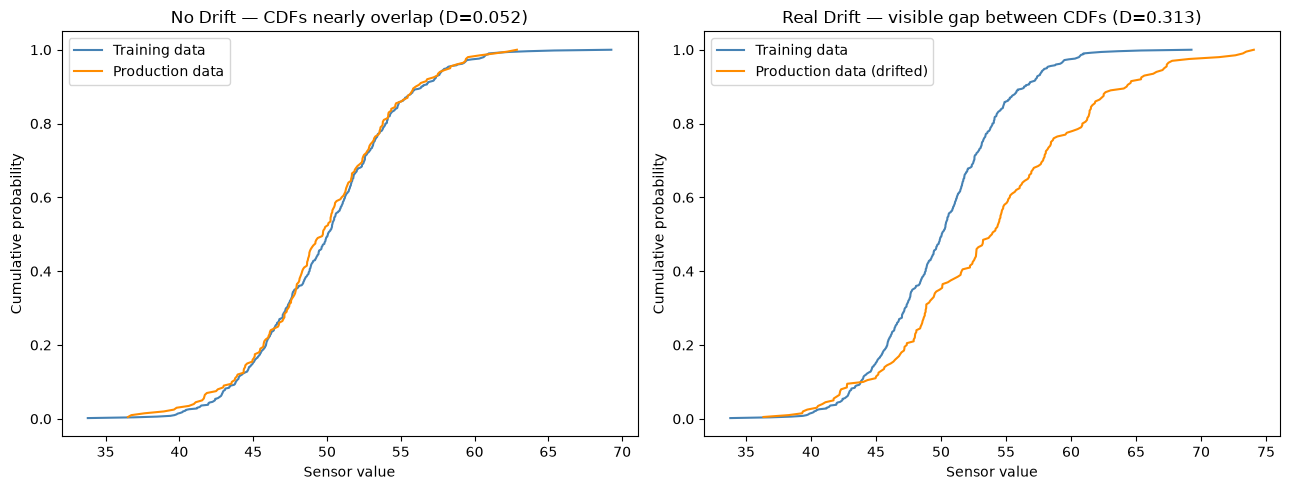

In [62]:
import matplotlib.pyplot as plt

def plot_ecdf(ax, data, label, color):
    # Empirical CDF: sort the data, then plot each point against its cumulative fraction
    sorted_data = np.sort(data)
    cumulative_frac = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cumulative_frac, label=label, color=color)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_ecdf(axes[0], training_data, 'Training data', 'steelblue')
plot_ecdf(axes[0], production_data_no_drift, 'Production data', 'darkorange')
axes[0].set_title(f'No Drift — CDFs nearly overlap (D={ks_stat_no_drift:.3f})')
axes[0].set_xlabel('Sensor value')
axes[0].set_ylabel('Cumulative probability')
axes[0].legend()

plot_ecdf(axes[1], training_data, 'Training data', 'steelblue')
plot_ecdf(axes[1], production_data_drifted, 'Production data (drifted)', 'darkorange')
axes[1].set_title(f'Real Drift — visible gap between CDFs (D={ks_stat_drift:.3f})')
axes[1].set_xlabel('Sensor value')
axes[1].set_ylabel('Cumulative probability')
axes[1].legend()

plt.tight_layout()
plt.show()

**Code:** Applying this as a practical drift-monitoring routine across multiple features at once — running the KS test feature-by-feature and flagging which ones show significant drift, the kind of check you'd automate for ongoing model monitoring.

In [63]:
import pandas as pd

# Simulate a small multi-feature "training" set and a "production" set, where
# only ONE feature has genuinely drifted, to show how you'd scan across many features at once
np.random.seed(42)
n_features = 5

training_set = pd.DataFrame({
    f'sensor_{i}': np.random.normal(loc=50, scale=5, size=500) for i in range(n_features)
})

production_set = pd.DataFrame({
    f'sensor_{i}': np.random.normal(loc=50, scale=5, size=200) for i in range(n_features)
})
production_set['sensor_2'] = np.random.normal(loc=58, scale=5, size=200)  # inject drift into just one sensor

drift_results = []
for col in training_set.columns:
    stat, p = stats.ks_2samp(training_set[col], production_set[col])
    drift_results.append({'feature': col, 'D_statistic': stat, 'p_value': p, 'drift_detected': p < 0.05})

drift_report = pd.DataFrame(drift_results)
print(drift_report)

    feature  D_statistic       p_value  drift_detected
0  sensor_0        0.068  5.062415e-01           False
1  sensor_1        0.061  6.442314e-01           False
2  sensor_2        0.574  3.639216e-44            True
3  sensor_3        0.086  2.305343e-01           False
4  sensor_4        0.064  5.840297e-01           False


### Explain shortly what Bayes Theorem is. Then explain how it is applicable in ML.

**Bayes Theorem** is a formula for updating a probability estimate as new evidence comes in — it tells you how to go from a **prior belief** to an **updated (posterior) belief**, given new data.

P(A|B) = [P(B|A) * P(A)] / P(B)

In plain terms:
- **P(A)** — the **prior** — how likely A was, before seeing any new evidence
- **P(B|A)** — the **likelihood** — how likely you'd see evidence B, if A were true
- **P(B)** — the overall probability of evidence B, regardless of A
- **P(A|B)** — the **posterior** — the *updated* probability of A, now that you've seen evidence B

**Simple everyday example:** imagine a disease that only 1% of the population actually has. There's a test for it that's 95% accurate — meaning it correctly flags 95% of people who truly have the disease, and correctly clears 95% of people who don't (so a 5% false-positive rate). You take the test and it comes back **positive**. What's the actual chance you have the disease?

Most people's gut instinct says "95%." But Bayes Theorem shows the real answer is **much lower** — often surprisingly around 16-17% in a scenario like this. Why? Because the disease is so rare (only 1% of people have it) that even a 5% false-positive rate, applied to the huge pool of healthy people, produces *more* false alarms than true positives. Your intuition ignored the **prior** (how rare the disease is) and focused only on the test's accuracy — that's exactly the mistake Bayes Theorem forces you to avoid.

**The general lesson:** a positive result on any test — a medical test, a spam filter, a fraud alert — is never automatically "probably true." How rare the thing you're testing for is (the prior) matters just as much as how accurate the test is.

### How it's applicable in ML

**1. Naive Bayes classifier** — a direct application. It classifies a data point by computing, for each possible class, the **posterior probability** of that class given the observed features, using Bayes Theorem. It's called "naive" because it assumes all features are independent given the class — a simplifying (often incorrect) assumption that still works surprisingly well in practice, especially for text classification.

**2. Bayesian statistics/inference more broadly** — an entire alternative philosophy of statistics (vs. the "frequentist" p-value/hypothesis-testing approach covered earlier). Instead of asking "how surprising is this data under a fixed null hypothesis," Bayesian methods directly compute a probability distribution over what parameter values are likely, updating a **prior belief** into a **posterior belief** as data arrives.

**3. Bayesian hyperparameter optimization** — this is your most directly relevant use case. Tools like **Optuna** use Bayesian optimization to intelligently search for good hyperparameter values — instead of blindly trying every combination (grid search) or randomly (random search), Bayesian optimization builds a probabilistic model of "which hyperparameter regions are likely to perform well," updating that belief after each trial, and uses it to decide where to search next. This is *why* Optuna converges to good hyperparameters faster than grid/random search.

**4. Bayesian A/B testing** — an alternative to the frequentist hypothesis testing framework covered earlier, directly stating "there's an 85% probability that version B is better than version A," rather than the more awkward frequentist framing via p-values.

**Relevance to your role:** Naive Bayes is a legitimate lightweight classical classifier worth having in your toolkit alongside Logistic Regression/Random Forest/XGBoost. But the most concrete day-to-day relevance is understanding *why* Optuna's Bayesian search works the way it does, since you'll be using it directly for hyperparameter tuning.

**Pipeline stage:** depends on the application — Naive Bayes is a **model** (chosen during model selection, trained like any other classifier); Bayesian optimization is part of the **hyperparameter tuning** stage.

**Code:** Working through the disease test example numerically — showing why a 95%-accurate test on a rare (1%) condition still produces a surprisingly low posterior probability of actually having it, given a positive result.

In [64]:
# Bayes Theorem applied to a diagnostic test scenario
# P(Disease) = prior probability a person has the disease
# P(Positive | Disease) = test sensitivity (true positive rate)
# P(Positive | No Disease) = false positive rate

p_disease = 0.01                  # prior: only 1% of the population actually has the disease
p_positive_given_disease = 0.95    # test correctly flags 95% of actual cases (sensitivity)
p_positive_given_no_disease = 0.05 # test incorrectly flags 5% of healthy people (false positive rate)

p_no_disease = 1 - p_disease  # 99% of people don't have the disease

# P(Positive) = P(Positive|Disease)*P(Disease) + P(Positive|No Disease)*P(No Disease)
# This is the "total probability" of testing positive, considering BOTH ways a positive test can happen
p_positive = (p_positive_given_disease * p_disease) + (p_positive_given_no_disease * p_no_disease)

# Bayes Theorem: P(Disease | Positive) = P(Positive | Disease) * P(Disease) / P(Positive)
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f"Prior probability of disease: {p_disease:.1%}")
print(f"Test sensitivity (true positive rate): {p_positive_given_disease:.1%}")
print(f"P(person tests positive): {p_positive:.4f}")
print(f"\nPosterior — P(actually has disease | tested positive): {p_disease_given_positive:.1%}")
print(f"\nDespite a 95%-accurate test, a positive result only means a "
      f"{p_disease_given_positive:.1%} actual chance of having the disease — because the disease is so rare.")

Prior probability of disease: 1.0%
Test sensitivity (true positive rate): 95.0%
P(person tests positive): 0.0590

Posterior — P(actually has disease | tested positive): 16.1%

Despite a 95%-accurate test, a positive result only means a 16.1% actual chance of having the disease — because the disease is so rare.


**Code:** Visualizing this with a population breakdown — showing, out of 10,000 people, exactly how many true positives vs. false positives the test produces, making the counterintuitive result visually concrete.

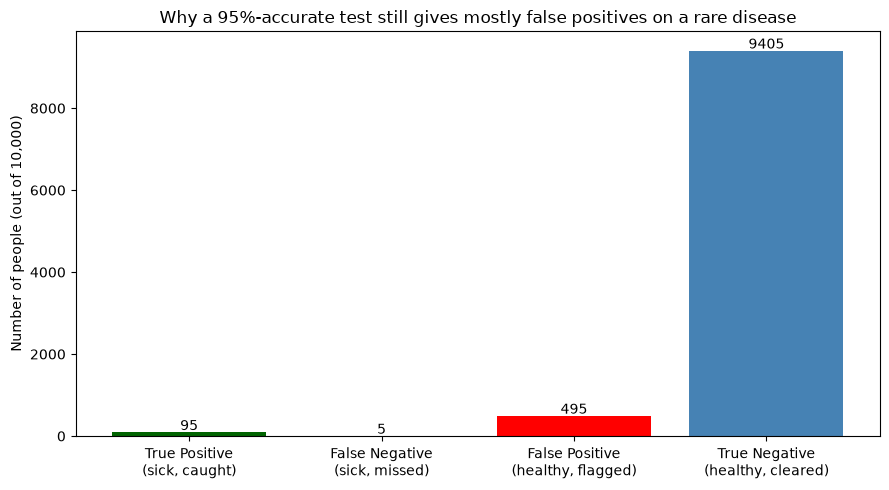

Out of 590 total positive results, only 95 are TRUE cases — the rest (495) are false alarms.


In [65]:
import matplotlib.pyplot as plt

n_total = 10000
n_diseased = int(n_total * p_disease)          # people who actually have the disease
n_healthy = n_total - n_diseased                 # people who don't

n_true_positive = int(n_diseased * p_positive_given_disease)      # diseased people correctly caught
n_false_negative = n_diseased - n_true_positive                     # diseased people missed
n_false_positive = int(n_healthy * p_positive_given_no_disease)   # healthy people incorrectly flagged
n_true_negative = n_healthy - n_false_positive                       # healthy people correctly cleared

categories = ['True Positive\n(sick, caught)', 'False Negative\n(sick, missed)',
              'False Positive\n(healthy, flagged)', 'True Negative\n(healthy, cleared)']
counts = [n_true_positive, n_false_negative, n_false_positive, n_true_negative]
colors = ['darkgreen', 'orange', 'red', 'steelblue']

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(categories, counts, color=colors)
ax.set_ylabel('Number of people (out of 10,000)')
ax.set_title('Why a 95%-accurate test still gives mostly false positives on a rare disease')
for i, count in enumerate(counts):
    ax.text(i, count + 50, str(count), ha='center')
plt.tight_layout()
plt.show()

print(f"Out of {n_true_positive + n_false_positive} total positive results, only "
      f"{n_true_positive} are TRUE cases — the rest ({n_false_positive}) are false alarms.")

**Code:** Applying Naive Bayes as an actual classifier on our shared dataset, and comparing it briefly to Logistic Regression — showing Bayes Theorem in action as a working ML model, not just a probability puzzle.

In [66]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# GaussianNB assumes each feature is normally distributed within each class,
# and applies Bayes Theorem to compute the posterior probability of each class
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Quick comparison against Logistic Regression on the same data
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

print(f"Naive Bayes accuracy:       {nb_model.score(X_test, y_test):.3f}")
print(f"Logistic Regression accuracy: {lr_model.score(X_test, y_test):.3f}")

# Naive Bayes gives direct posterior probabilities per class, computed via Bayes Theorem
sample_probs = nb_model.predict_proba(X_test[:5])
print(f"\nPosterior probabilities for first 5 test samples (P(class=0), P(class=1)):")
print(sample_probs)

Naive Bayes accuracy:       0.790
Logistic Regression accuracy: 0.840

Posterior probabilities for first 5 test samples (P(class=0), P(class=1)):
[[0.96811998 0.03188002]
 [0.21408397 0.78591603]
 [0.99896835 0.00103165]
 [0.88923074 0.11076926]
 [0.91986884 0.08013116]]
